# 12. Visualization Notebook

Visualizes system performance from **live ablation benchmarks** (not hardcoded values).

## Production stack (AWS Bedrock)
| Agent | Model |
|-------|-------|
| Designer / Validator | `anthropic.claude-sonnet-4-6` |
| Optimizer | `anthropic.claude-opus-4-6-v1` (`use_rl: false`) |
| Educational | `anthropic.claude-haiku-4-5-20251001-v1:0` |
| Embeddings | `amazon.nova-2-multimodal-embeddings-v1:0` |

- **25 prompts** in `data/datasets/benchmark_prompts_v2.jsonl` (code tiers only for ablation)
- **RAG:** top_k=5, similarity_threshold=0.7


## 1. Setup and Imports

In [ ]:
import sys
import os
from pathlib import Path
import cirq
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import pandas as pd
from math import pi

# Add project root to path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Change working directory to project root
os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")

from src.cirq_rag_code_assistant.config import get_config
from src.cirq_rag_code_assistant.config.logging import setup_default_logging
from src.rag.embeddings import EmbeddingModel
from src.rag.vector_store import VectorStore
from src.rag.knowledge_base import KnowledgeBase
from src.tools.analyzer import CircuitAnalyzer

# Setup
setup_default_logging()

# Set matplotlib style for beautiful visualizations
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.3
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Create results directory
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)
print(f"📁 Results will be saved to: {results_dir}")

print("✅ Visualization modules loaded!")

Working directory: D:\Study Material\FYP\Practice\Test8\QCanvas\Cirq-RAG-Code-Assistant
{"text": "2026-05-19 00:59:44.339 | INFO     | src.cirq_rag_code_assistant.config.logging:setup_all:152 - Logging configuration completed\n", "record": {"elapsed": {"repr": "0:00:03.293553", "seconds": 3.293553}, "exception": null, "extra": {"log_level": "INFO", "log_file": "outputs/logs/cirq_rag.log", "format": "json"}, "file": {"name": "logging.py", "path": "D:\\Study Material\\FYP\\Practice\\Test8\\QCanvas\\Cirq-RAG-Code-Assistant\\src\\cirq_rag_code_assistant\\config\\logging.py"}, "function": "setup_all", "level": {"icon": "ℹ️", "name": "INFO", "no": 20}, "line": 152, "message": "Logging configuration completed", "module": "logging", "name": "src.cirq_rag_code_assistant.config.logging", "process": {"id": 25432, "name": "MainProcess"}, "thread": {"id": 25112, "name": "MainThread"}, "time": {"repr": "2026-05-19 00:59:44.339504+05:00", "timestamp": 1779134384.339504}}}
📁 Results will be saved to: 

In [ ]:
import sys
import os
from pathlib import Path
import cirq
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import pandas as pd
from math import pi

# Add project root to path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Change working directory to project root
os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")

from src.cirq_rag_code_assistant.config import get_config
from src.cirq_rag_code_assistant.config.logging import setup_default_logging
from src.rag.embeddings import EmbeddingModel
from src.rag.vector_store import VectorStore
from src.rag.knowledge_base import KnowledgeBase
from src.tools.analyzer import CircuitAnalyzer

# Setup
setup_default_logging()

# Set matplotlib style for beautiful visualizations
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.3
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Create results directory
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)
print(f"📁 Results will be saved to: {results_dir}")

print("✅ Visualization modules loaded!")

Working directory: D:\Study Material\FYP\Practice\Test8\QCanvas\Cirq-RAG-Code-Assistant
{"text": "2026-05-19 00:59:44.339 | INFO     | src.cirq_rag_code_assistant.config.logging:setup_all:152 - Logging configuration completed\n", "record": {"elapsed": {"repr": "0:00:03.293553", "seconds": 3.293553}, "exception": null, "extra": {"log_level": "INFO", "log_file": "outputs/logs/cirq_rag.log", "format": "json"}, "file": {"name": "logging.py", "path": "D:\\Study Material\\FYP\\Practice\\Test8\\QCanvas\\Cirq-RAG-Code-Assistant\\src\\cirq_rag_code_assistant\\config\\logging.py"}, "function": "setup_all", "level": {"icon": "ℹ️", "name": "INFO", "no": 20}, "line": 152, "message": "Logging configuration completed", "module": "logging", "name": "src.cirq_rag_code_assistant.config.logging", "process": {"id": 25432, "name": "MainProcess"}, "thread": {"id": 25112, "name": "MainThread"}, "time": {"repr": "2026-05-19 00:59:44.339504+05:00", "timestamp": 1779134384.339504}}}
📁 Results will be saved to: 

## 2. Circuit Examples

Sample quantum circuits for reference.

In [ ]:
# Create sample circuit
q0, q1 = cirq.LineQubit.range(2)
bell_circuit = cirq.Circuit(
    cirq.H(q0),
    cirq.CNOT(q0, q1),
    cirq.measure(q0, q1, key='result')
)

print("📊 Bell State Circuit:")
print(bell_circuit)

# Analyze it
analyzer = CircuitAnalyzer()
analysis = analyzer.analyze(bell_circuit)
print("\nCircuit Metrics:")
for metric, value in analysis['metrics'].items():
    print(f"  {metric}: {value}")

📊 Bell State Circuit:
0: ───H───@───M('result')───
          │   │
1: ───────X───M─────────────

Circuit Metrics:
  num_qubits: 2
  depth: 3
  num_operations: 3
  num_moments: 3
  num_measurements: 1


## 3. System Mode Comparison

Runs `AblationStudy` across six variants on the v2 benchmark suite.
Results are cached to `results/ablation_results.json` — delete that file to force a re-run.

**Note:** Full 25-prompt × 6-variant runs are expensive (AWS Bedrock). Use `MAX_BENCHMARK_CASES`
for a subset during development.

In [3]:
# Run ablation study (or load cached results)
import json
from src.evaluation.ablation import AblationStudy, VARIANT_LABELS
from src.evaluation.benchmark import load_benchmark_prompts

# --- Configuration ---
RUN_ABLATION = True          # Set False to only load cached results
MAX_BENCHMARK_CASES = 5      # None = all 25 code prompts; use 5 for quick dev runs
ABLATION_CACHE = results_dir / "ablation_results.json"

benchmark_cases = load_benchmark_prompts(exclude_explanation=True)
print(f"Benchmark prompts loaded: {len(benchmark_cases)} (code tiers only)")

if RUN_ABLATION:
    study = AblationStudy(benchmark_cases=benchmark_cases)
    variants = list(VARIANT_LABELS.keys())
    print(f"Running ablation: {len(variants)} variants × {MAX_BENCHMARK_CASES or len(benchmark_cases)} prompts...")
    ablation_raw = study.run_study(variants=variants, max_cases=MAX_BENCHMARK_CASES)
    study.save_results(ABLATION_CACHE, ablation_raw)
else:
    if ABLATION_CACHE.exists():
        ablation_raw = AblationStudy.load_results(ABLATION_CACHE)
        study = AblationStudy()
        study.results = ablation_raw
    else:
        raise FileNotFoundError(f"No cache at {ABLATION_CACHE}; set RUN_ABLATION=True")

modes = study.aggregate_to_modes_dict(ablation_raw if RUN_ABLATION else study.results)
mode_names = list(modes.keys())

print(f"\n📊 Comparing {len(mode_names)} system modes (from benchmarks)")
for name in mode_names:
    m = modes[name]
    print(f"\n{name}:")
    print(f"  Components: {', '.join(m['components'])}")
    print(f"  Success: {m['success_rate']:.1%} | Validation: {m['validation_rate']:.1%} | "
          f"Latency: {m['avg_latency']:.1f}±{m['latency_std']:.1f}s | Quality: {m['code_quality']:.2f}")


{"text": "2026-05-19 00:59:46.740 | INFO     | config.config_loader:load:118 - ✅ Loaded configuration from D:\\Study Material\\FYP\\Practice\\Test8\\QCanvas\\Cirq-RAG-Code-Assistant\\config\\config.json\n", "record": {"elapsed": {"repr": "0:00:05.694623", "seconds": 5.694623}, "exception": null, "extra": {"name": "config.config_loader"}, "file": {"name": "config_loader.py", "path": "D:\\Study Material\\FYP\\Practice\\Test8\\QCanvas\\Cirq-RAG-Code-Assistant\\config\\config_loader.py"}, "function": "load", "level": {"icon": "ℹ️", "name": "INFO", "no": 20}, "line": 118, "message": "✅ Loaded configuration from D:\\Study Material\\FYP\\Practice\\Test8\\QCanvas\\Cirq-RAG-Code-Assistant\\config\\config.json", "module": "config_loader", "name": "config.config_loader", "process": {"id": 25432, "name": "MainProcess"}, "thread": {"id": 25112, "name": "MainThread"}, "time": {"repr": "2026-05-19 00:59:46.740574+05:00", "timestamp": 1779134386.740574}}}
{"text": "2026-05-19 00:59:46.751 | INFO     |

Benchmark prompts loaded: 20 (code tiers only)
2026-05-19 00:59:46,785 - botocore.credentials - INFO - credentials.py:1252 - Found credentials in environment variables.
{"text": "2026-05-19 00:59:47.257 | INFO     | src.rag.embeddings:_init_aws:124 - Using AWS Bedrock Embeddings: amazon.nova-2-multimodal-embeddings-v1:0, dim=1024\n", "record": {"elapsed": {"repr": "0:00:06.211192", "seconds": 6.211192}, "exception": null, "extra": {"name": "src.rag.embeddings"}, "file": {"name": "embeddings.py", "path": "D:\\Study Material\\FYP\\Practice\\Test8\\QCanvas\\Cirq-RAG-Code-Assistant\\src\\rag\\embeddings.py"}, "function": "_init_aws", "level": {"icon": "ℹ️", "name": "INFO", "no": 20}, "line": 124, "message": "Using AWS Bedrock Embeddings: amazon.nova-2-multimodal-embeddings-v1:0, dim=1024", "module": "embeddings", "name": "src.rag.embeddings", "process": {"id": 25432, "name": "MainProcess"}, "thread": {"id": 25112, "name": "MainThread"}, "time": {"repr": "2026-05-19 00:59:47.257143+05:00", 

### 3.1 Performance Metrics Overview

**Code Quality Formula (published, §4.3):**
```
CodeQuality(c) = 0.30 × SyntaxValid(c)
              + 0.30 × CompilationSuccess(c)
              + 0.20 × HasMeasurement(c)
              + 0.10 × CircuitNonEmpty(c)
              + 0.10 × CorrectImports(c)
```

Values come from `compute_code_quality_score()` during each benchmark run — not re-derived in plots.

✅ Using benchmark-derived code quality scores (published formula)
✅ Saved: mode_success_rate.png


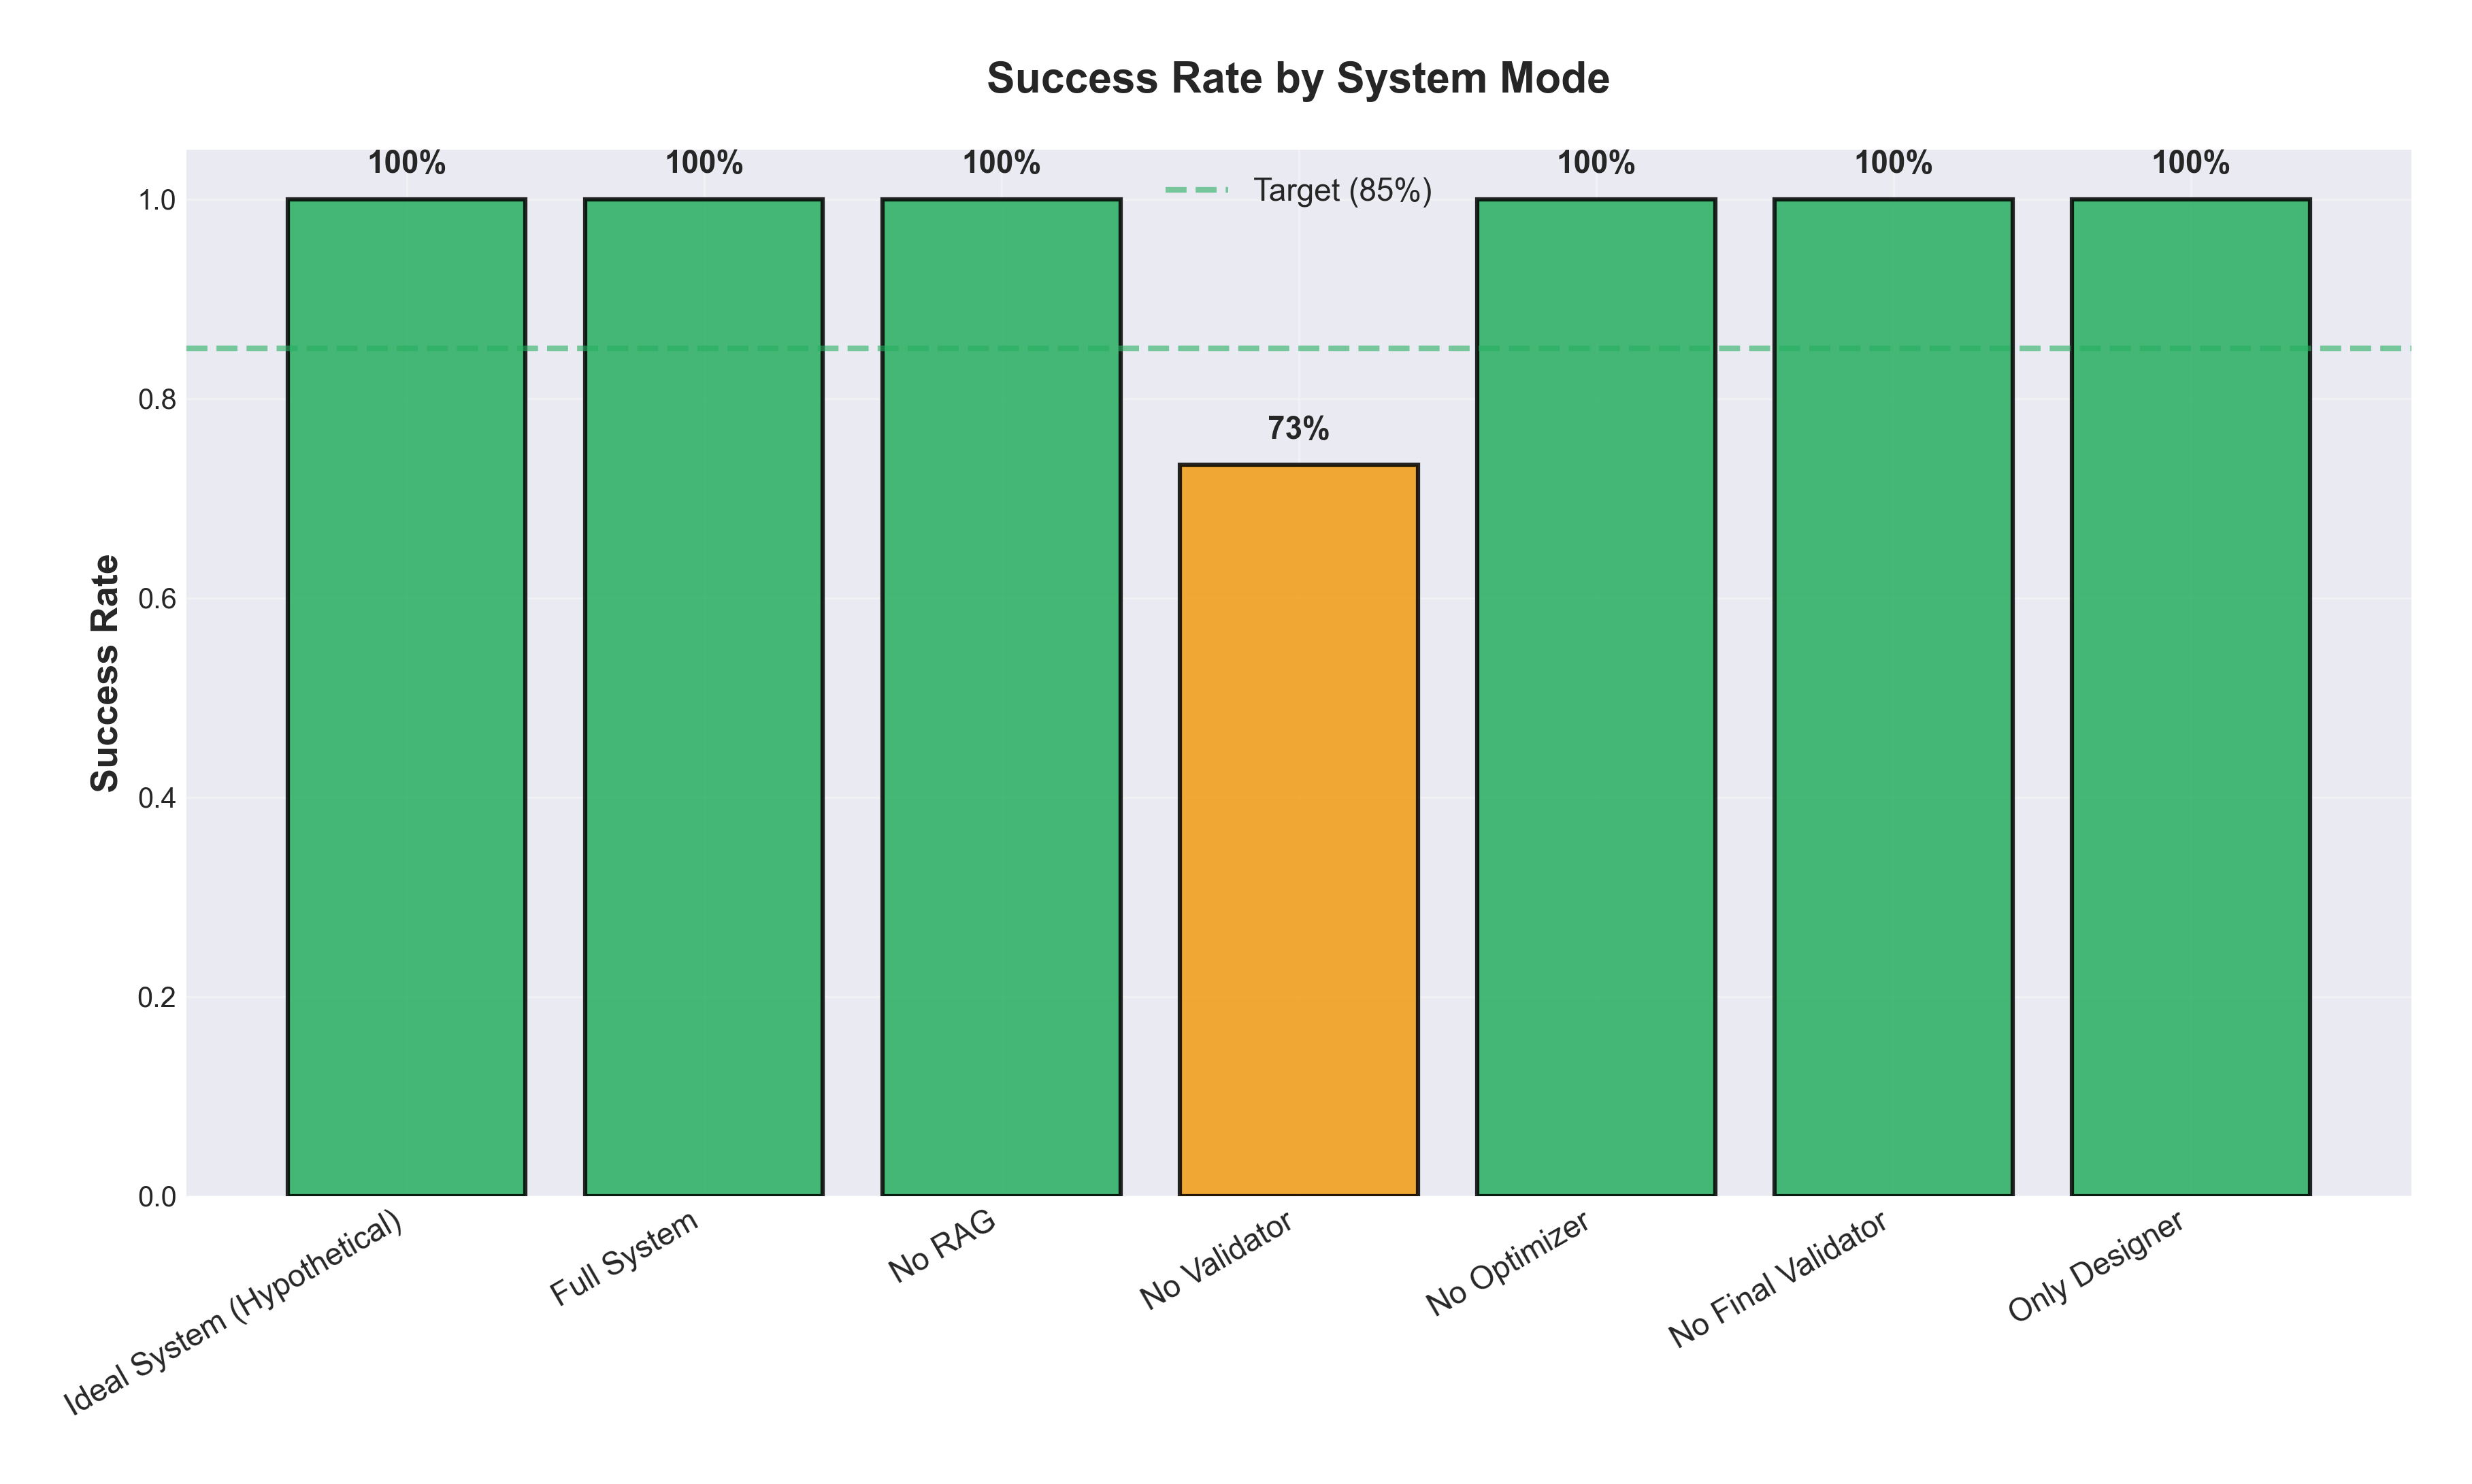

✅ Saved: mode_latency.png


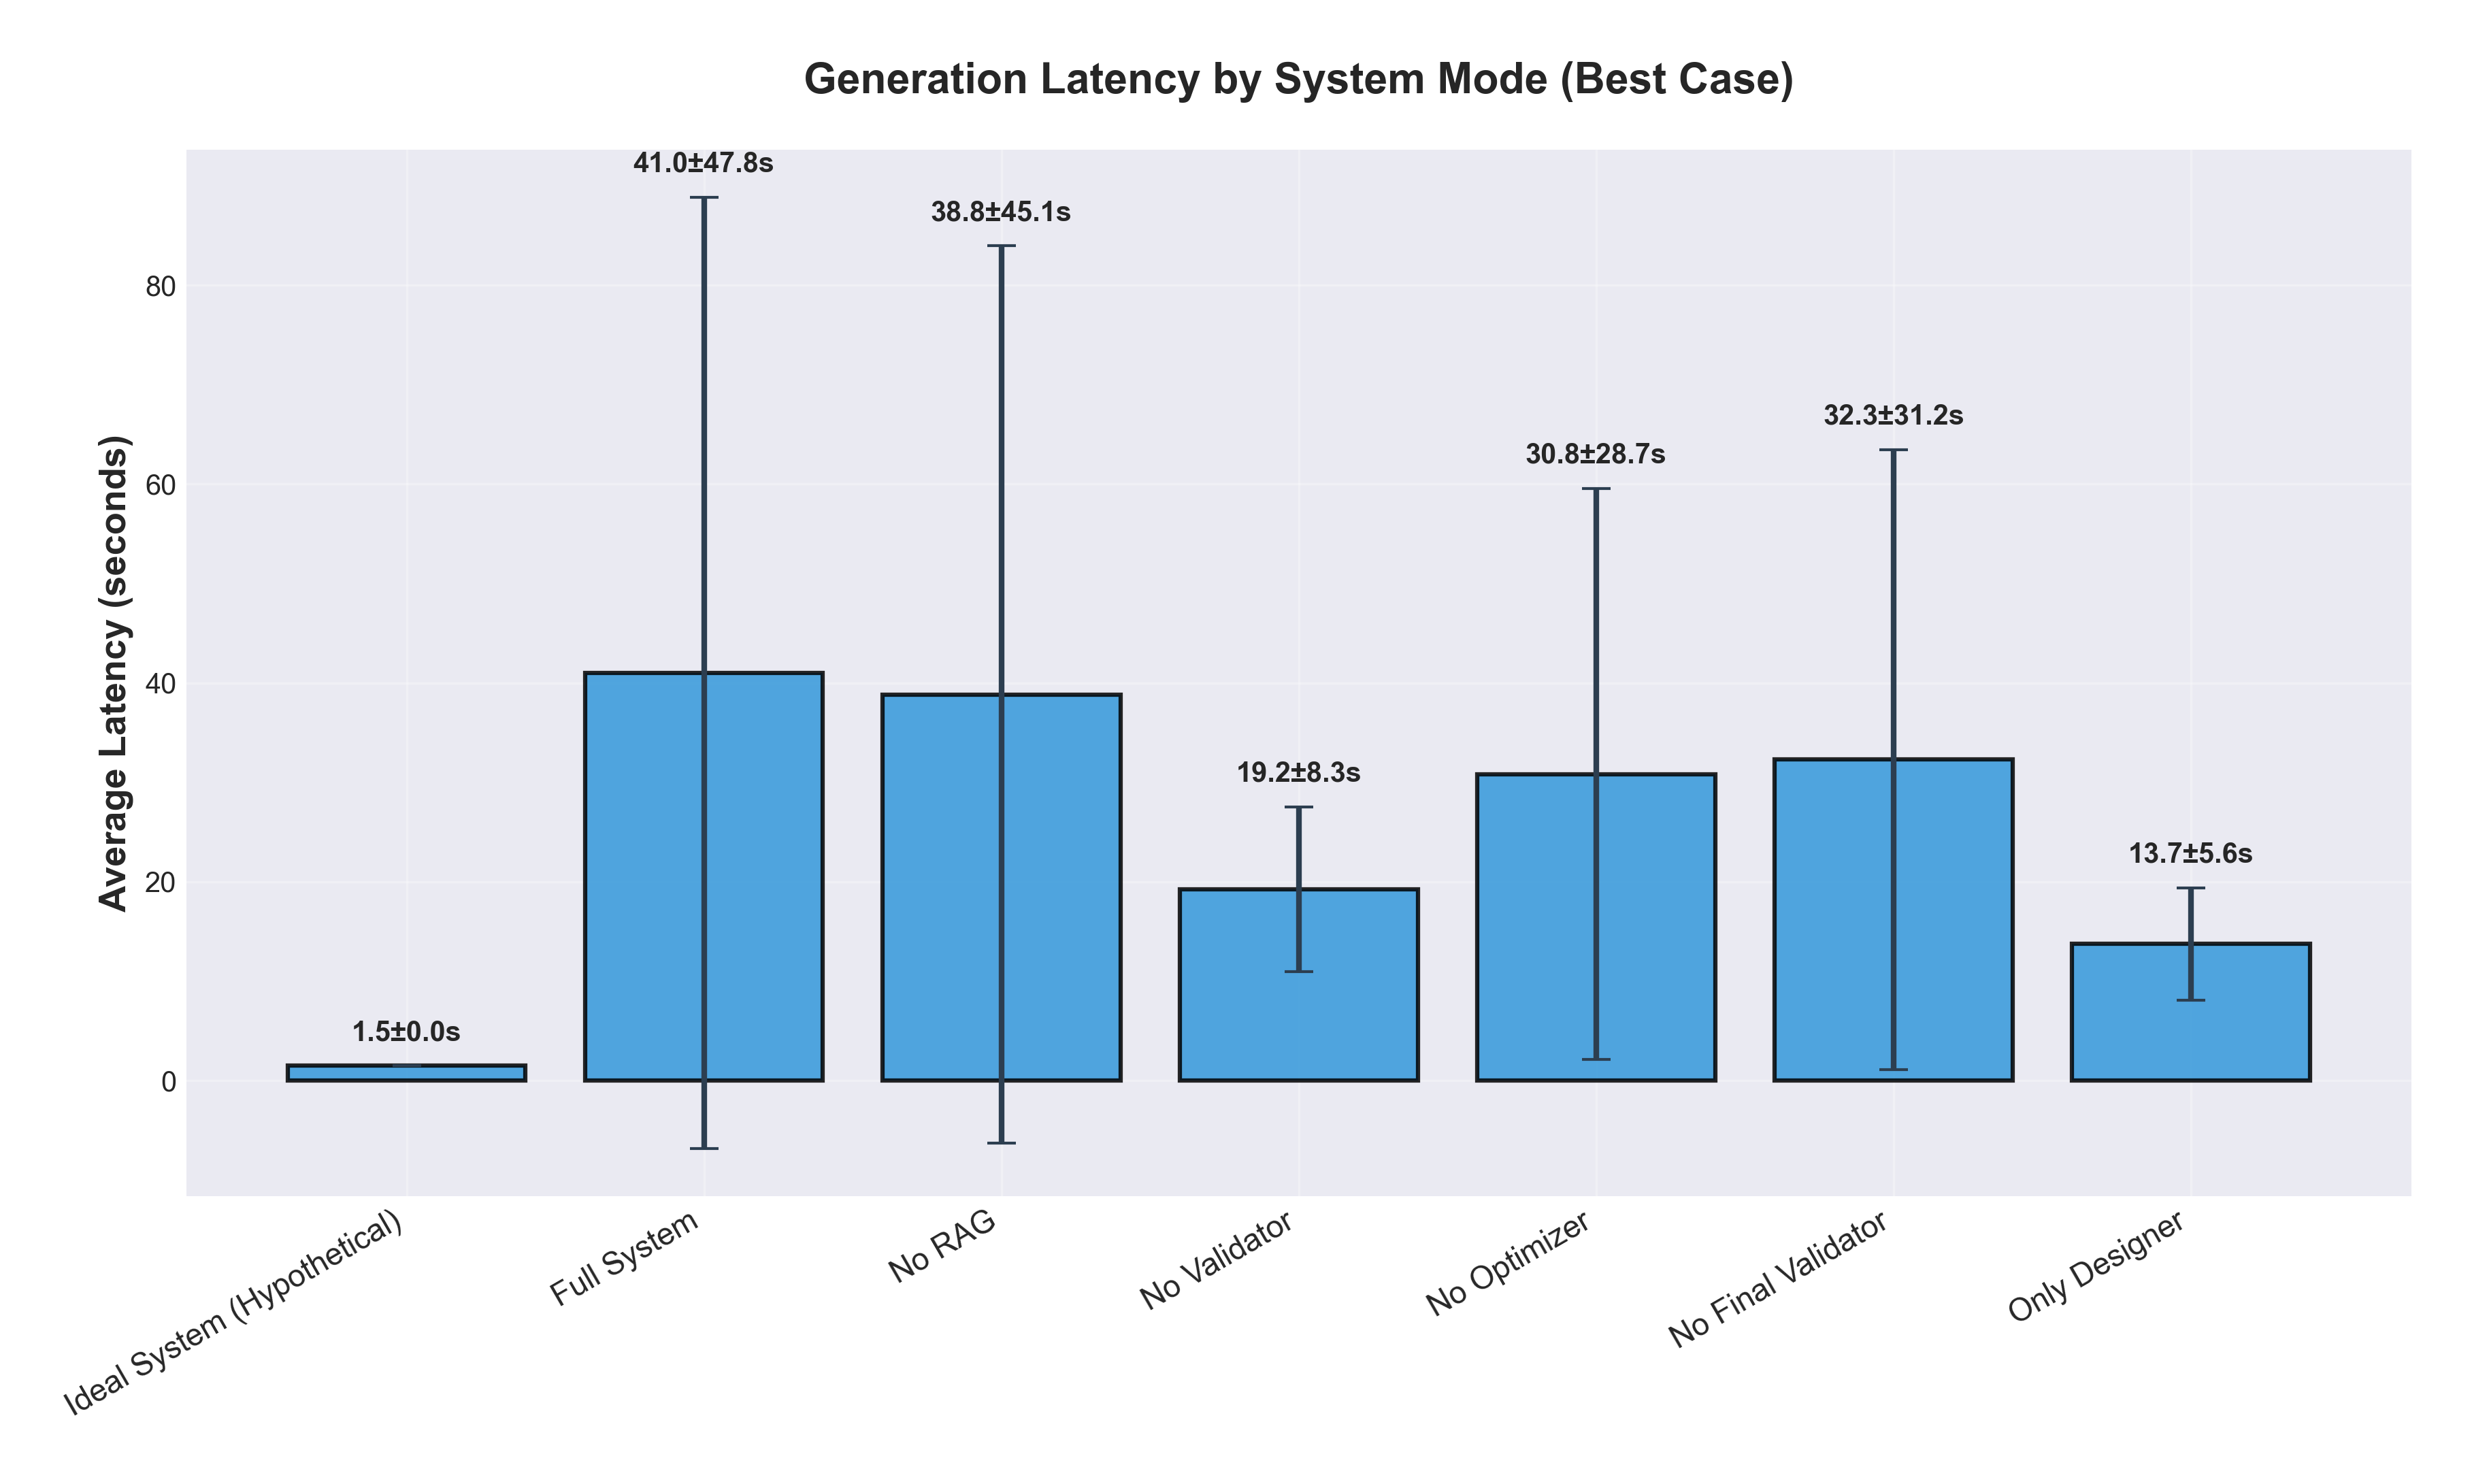

✅ Saved: mode_validation_rate.png


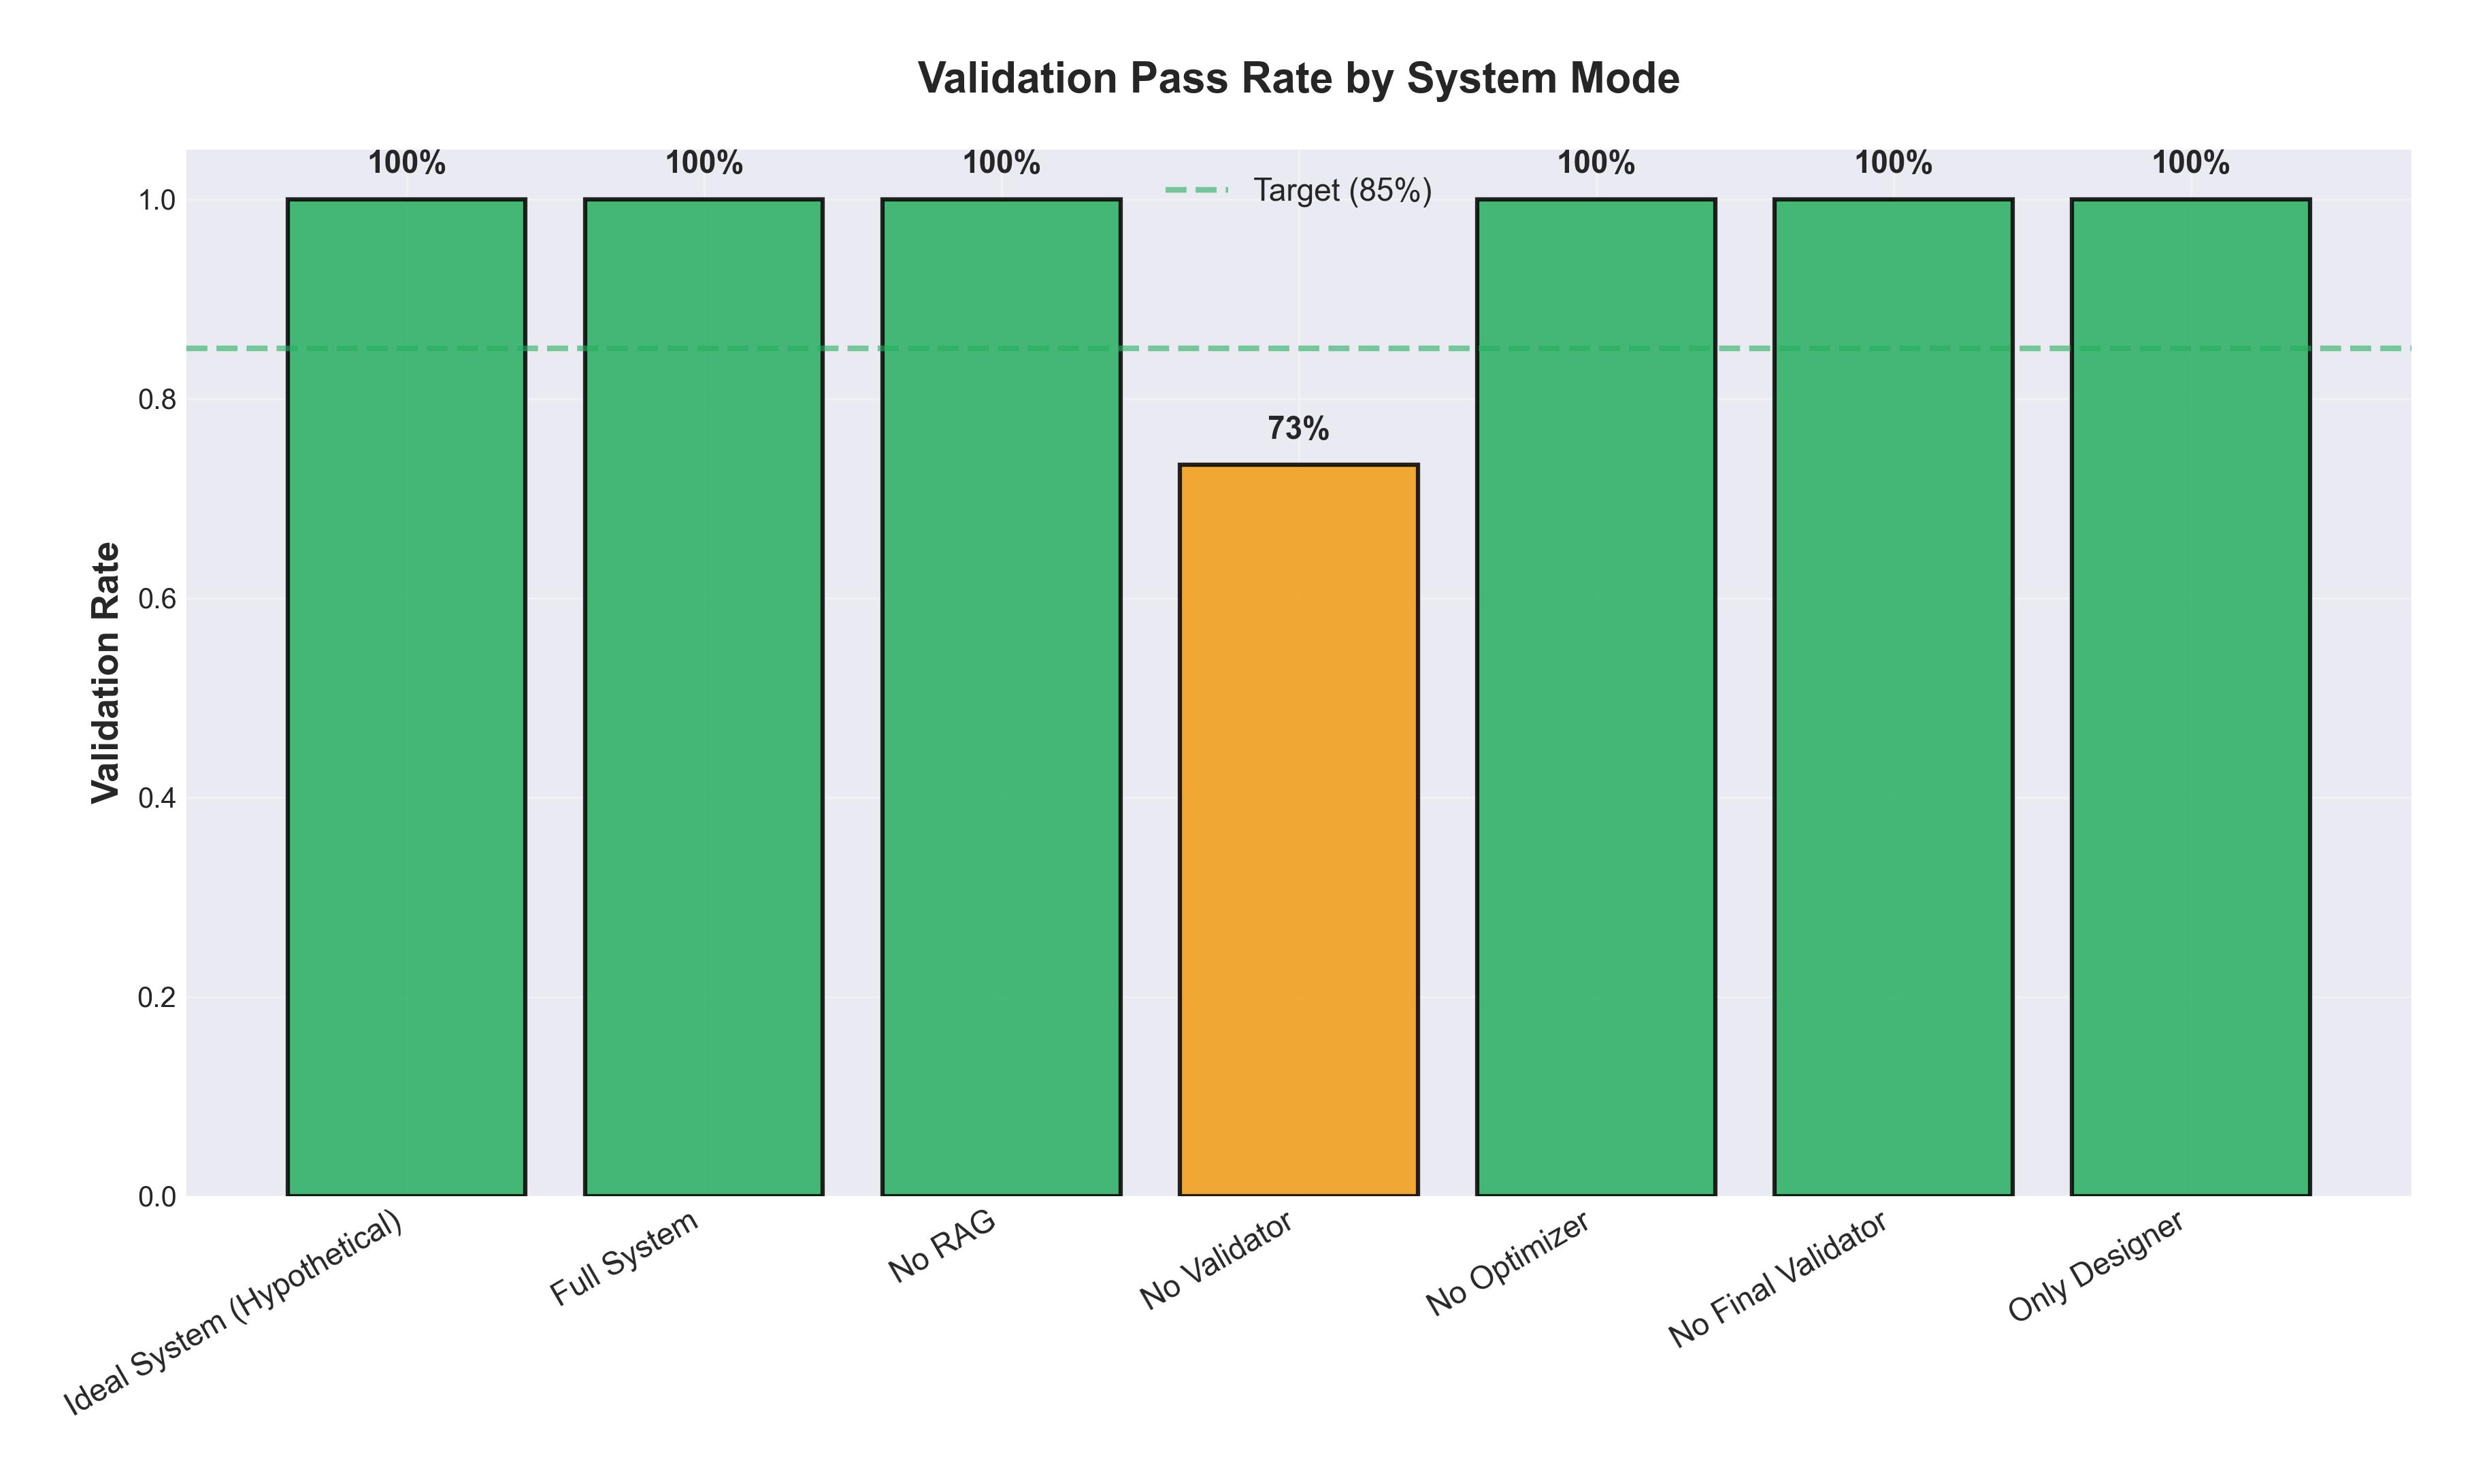

✅ Saved: mode_code_quality.png


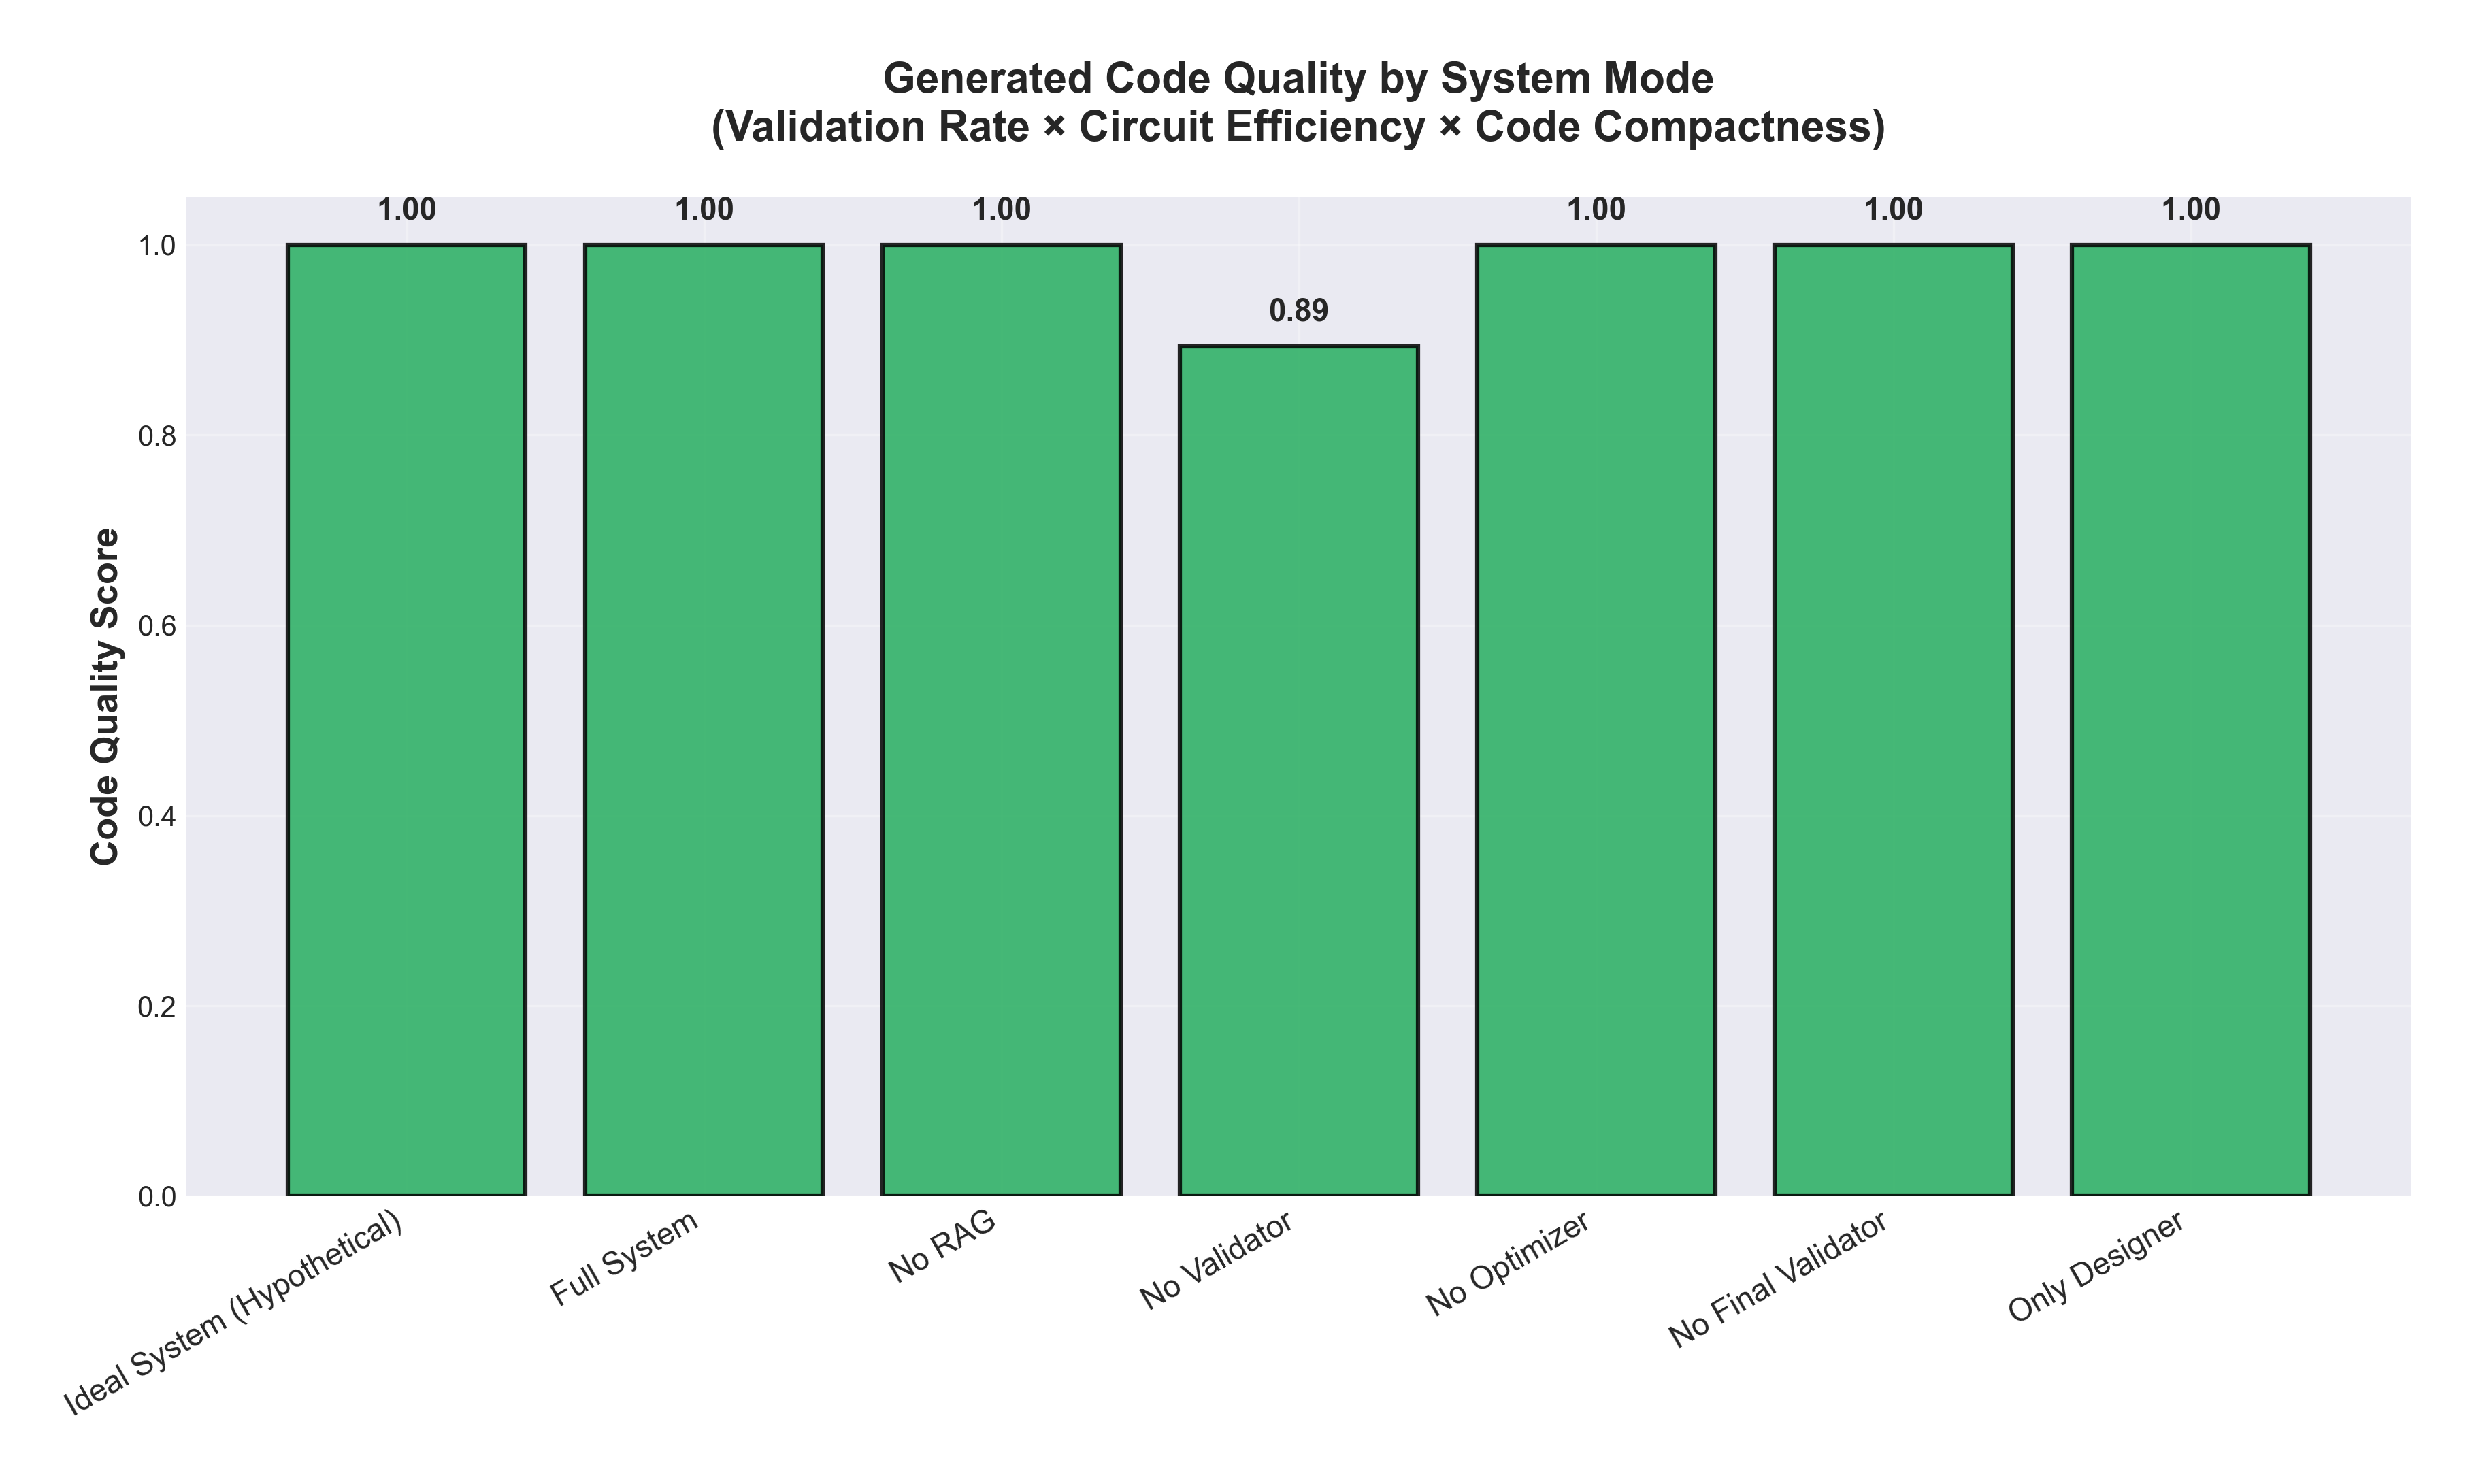

In [11]:
# Performance metrics from benchmark-derived `modes` dict
success_rates = [modes[n]["success_rate"] for n in mode_names]
validation_rates = [modes[n]["validation_rate"] for n in mode_names]
code_qualities = [modes[n]["code_quality"] for n in mode_names]
latencies = [modes[n]["avg_latency"] for n in mode_names]
latency_stds = [modes[n]["latency_std"] for n in mode_names]
depths = [modes[n]["circuit_depth"] for n in mode_names]
num_gates = [modes[n]["num_gates"] for n in mode_names]
two_qubit = [modes[n]["two_qubit_gates"] for n in mode_names]
code_lengths = [modes[n]["code_length"] for n in mode_names]

print("✅ Using benchmark-derived code quality scores (published formula)")

# Performance metrics - Success Rate
# Performance metrics - Success Rate
fig, ax = plt.subplots(figsize=(12, 7))

success_rates = [modes[m]["success_rate"] for m in mode_names]
colors_success = ['#27ae60' if s >= 0.85 else '#f39c12' if s >= 0.70 else '#e74c3c' for s in success_rates]
bars = ax.bar(range(len(mode_names)), success_rates, color=colors_success, alpha=0.85, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Success Rate', fontweight='bold', fontsize=13)
ax.set_title('Success Rate by System Mode', fontweight='bold', fontsize=15, pad=20)
ax.set_xticks(range(len(mode_names)))
ax.set_xticklabels(mode_names, rotation=30, ha='right', fontsize=11)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.85, color='#27ae60', linestyle='--', alpha=0.6, linewidth=2, label='Target (85%)')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for i, (bar, rate) in enumerate(zip(bars, success_rates)):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.02, 
            f'{rate:.0%}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(results_dir / 'mode_success_rate.png', dpi=300, bbox_inches='tight')
print(f"✅ Saved: mode_success_rate.png")
plt.show()

# Latency with error bars
fig, ax = plt.subplots(figsize=(12, 7))
latencies = [modes[m]["avg_latency"] for m in mode_names]
latency_stds = [modes[m]["latency_std"] for m in mode_names]
bars = ax.bar(range(len(mode_names)), latencies, yerr=latency_stds, 
              color='#3498db', alpha=0.85, edgecolor='black', linewidth=1.5, 
              capsize=5, error_kw={'linewidth': 2, 'ecolor': '#2c3e50'})
ax.set_ylabel('Average Latency (seconds)', fontweight='bold', fontsize=13)
ax.set_title('Generation Latency by System Mode (Best Case)', fontweight='bold', fontsize=15, pad=20)
ax.set_xticks(range(len(mode_names)))
ax.set_xticklabels(mode_names, rotation=30, ha='right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

for i, (bar, lat, std) in enumerate(zip(bars, latencies, latency_stds)):
    ax.text(bar.get_x() + bar.get_width()/2, lat + std + 2, 
            f'{lat:.1f}±{std:.1f}s', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(results_dir / 'mode_latency.png', dpi=300, bbox_inches='tight')
print(f"✅ Saved: mode_latency.png")
plt.show()

# Validation Rate
fig, ax = plt.subplots(figsize=(12, 7))
colors_val = ['#27ae60' if v >= 0.85 else '#f39c12' if v >= 0.70 else '#e74c3c' for v in validation_rates]
bars = ax.bar(range(len(mode_names)), validation_rates, color=colors_val, alpha=0.85, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Validation Rate', fontweight='bold', fontsize=13)
ax.set_title('Validation Pass Rate by System Mode', fontweight='bold', fontsize=15, pad=20)
ax.set_xticks(range(len(mode_names)))
ax.set_xticklabels(mode_names, rotation=30, ha='right', fontsize=11)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.85, color='#27ae60', linestyle='--', alpha=0.6, linewidth=2, label='Target (85%)')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for i, (bar, rate) in enumerate(zip(bars, validation_rates)):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.02, 
            f'{rate:.0%}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(results_dir / 'mode_validation_rate.png', dpi=300, bbox_inches='tight')
print(f"✅ Saved: mode_validation_rate.png")
plt.show()

# Code Quality
fig, ax = plt.subplots(figsize=(12, 7))
code_qualities = [modes[m]["code_quality"] for m in mode_names]
colors_quality = ['#27ae60' if q >= 0.80 else '#f39c12' if q >= 0.65 else '#e74c3c' for q in code_qualities]
bars = ax.bar(range(len(mode_names)), code_qualities, color=colors_quality, alpha=0.85, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Code Quality Score', fontweight='bold', fontsize=13)
ax.set_title('Generated Code Quality by System Mode\n(Validation Rate × Circuit Efficiency × Code Compactness)', 
             fontweight='bold', fontsize=15, pad=20)
ax.set_xticks(range(len(mode_names)))
ax.set_xticklabels(mode_names, rotation=30, ha='right', fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

for i, (bar, quality) in enumerate(zip(bars, code_qualities)):
    ax.text(bar.get_x() + bar.get_width()/2, quality + 0.02, 
            f'{quality:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(results_dir / 'mode_code_quality.png', dpi=300, bbox_inches='tight')
print(f"✅ Saved: mode_code_quality.png")
plt.show()

### 3.2 Circuit Quality Metrics

✅ Saved: mode_circuit_depth.png


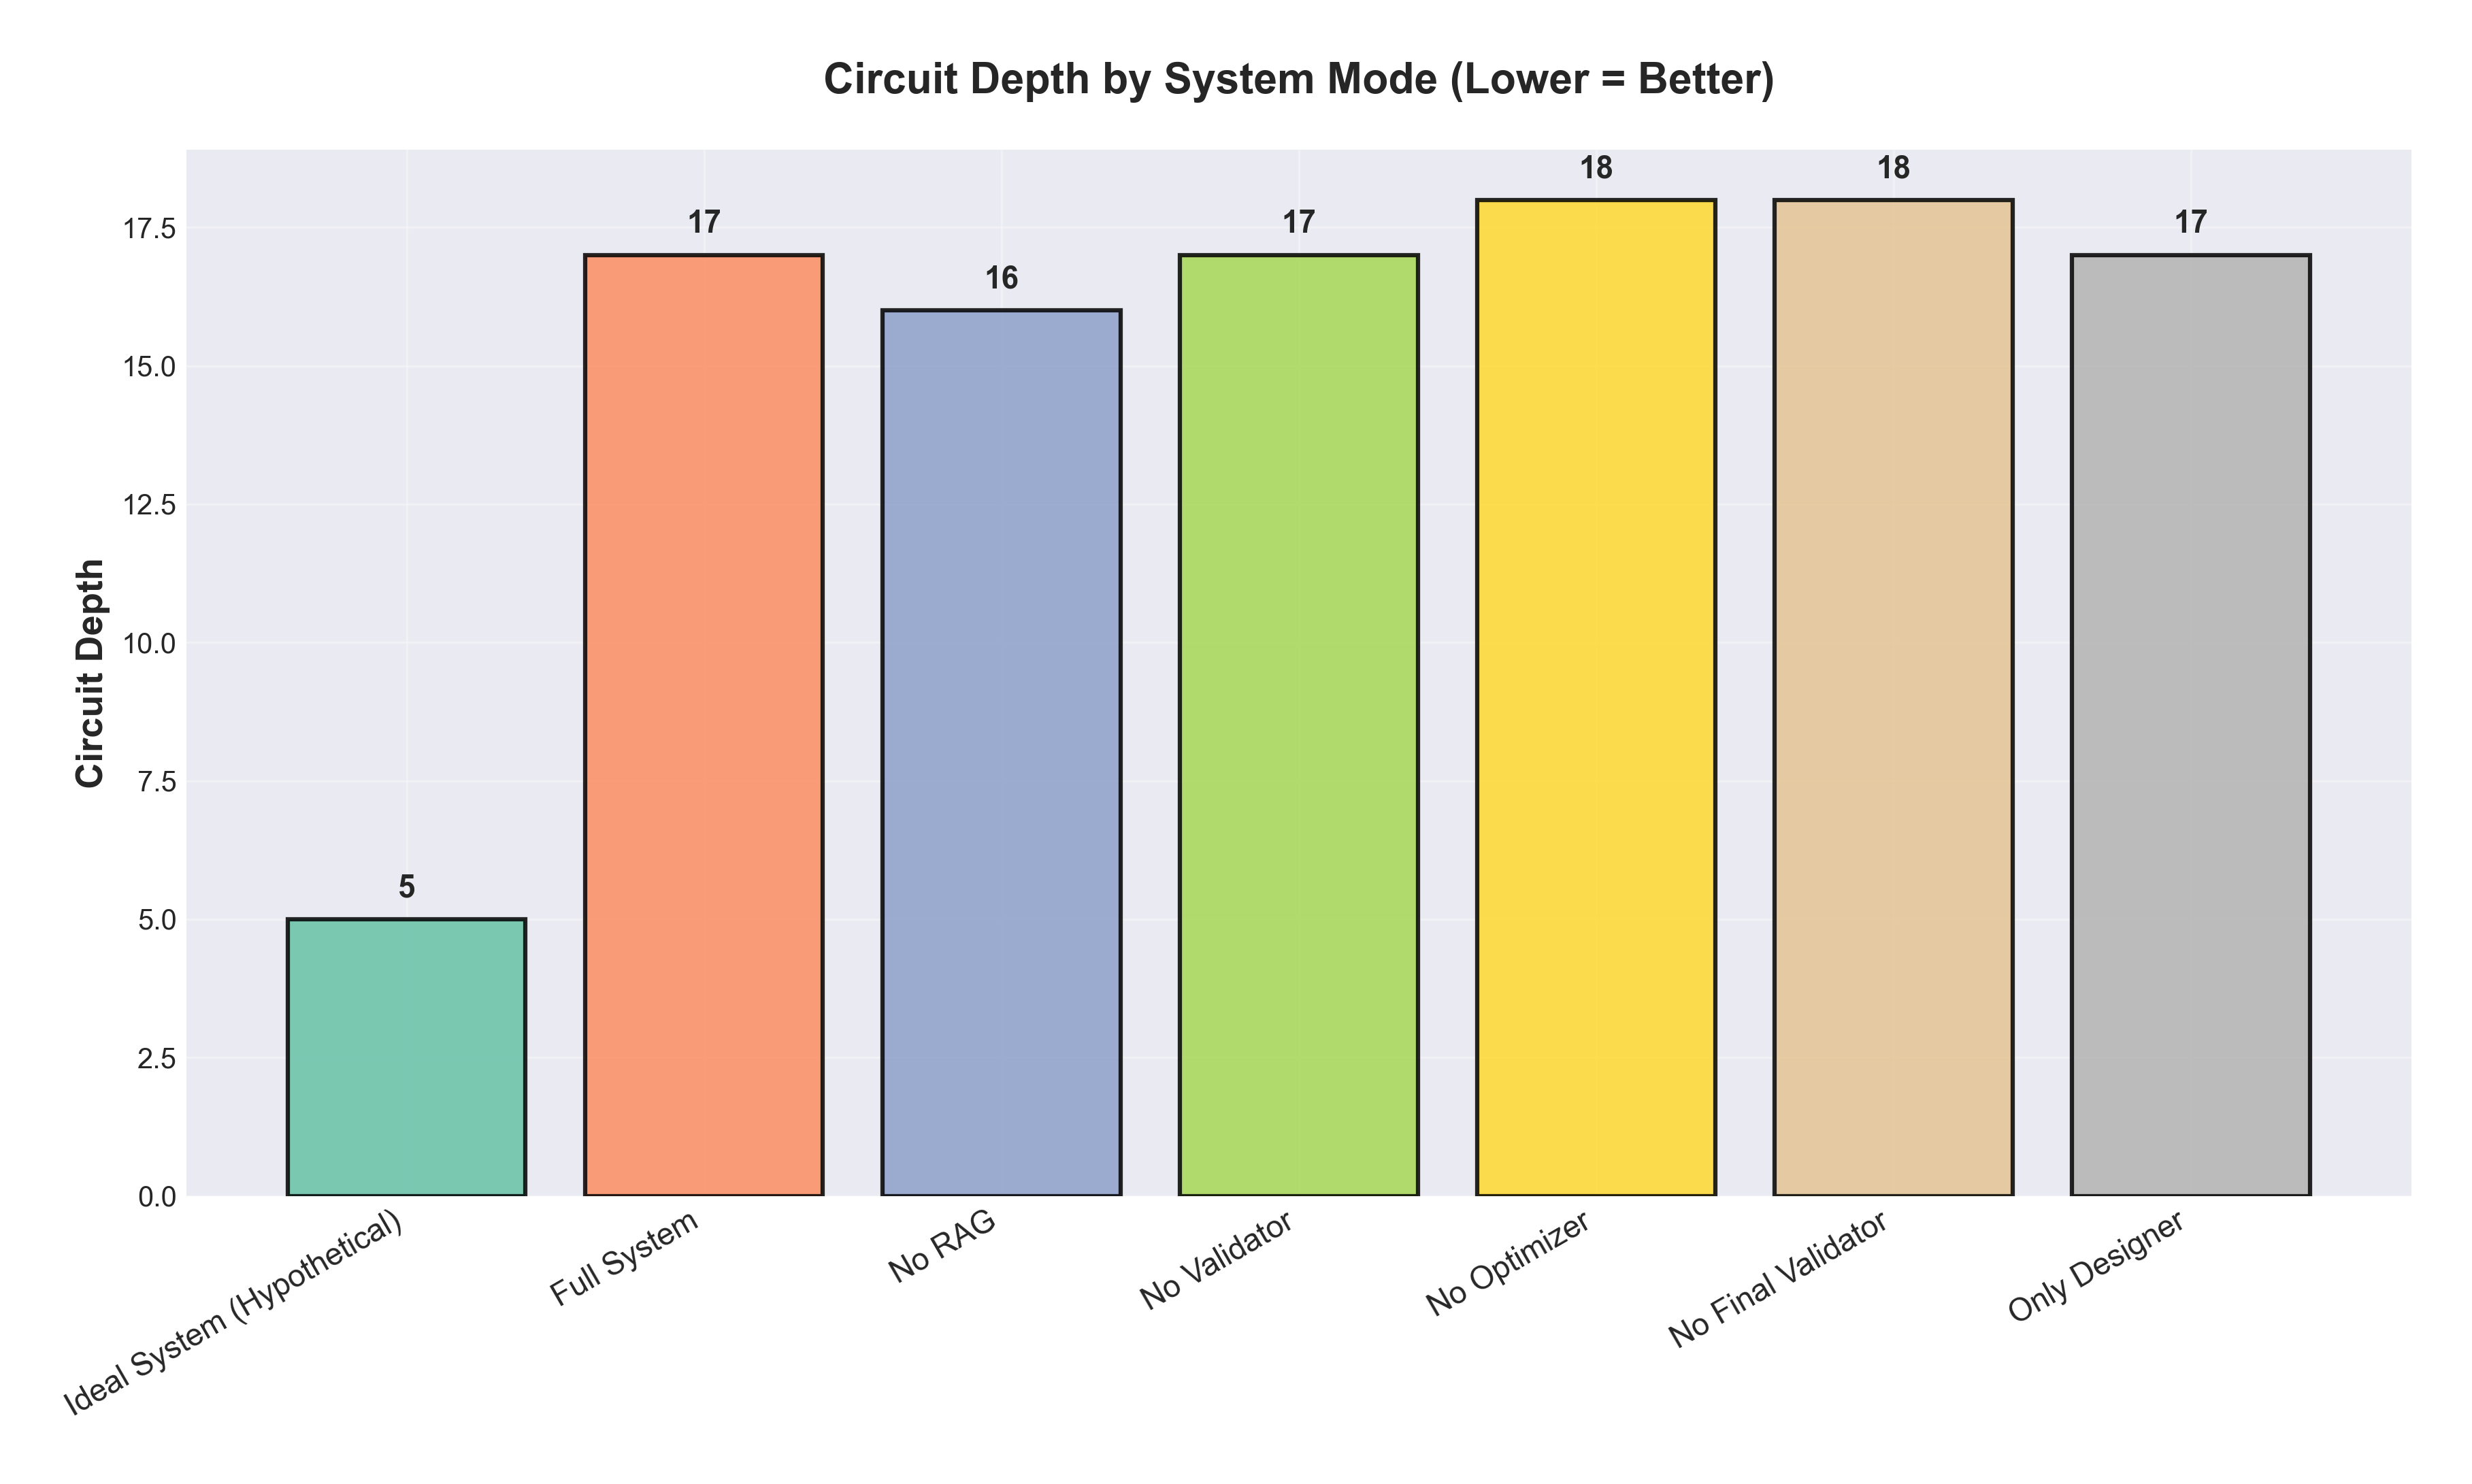

✅ Saved: mode_total_gates.png


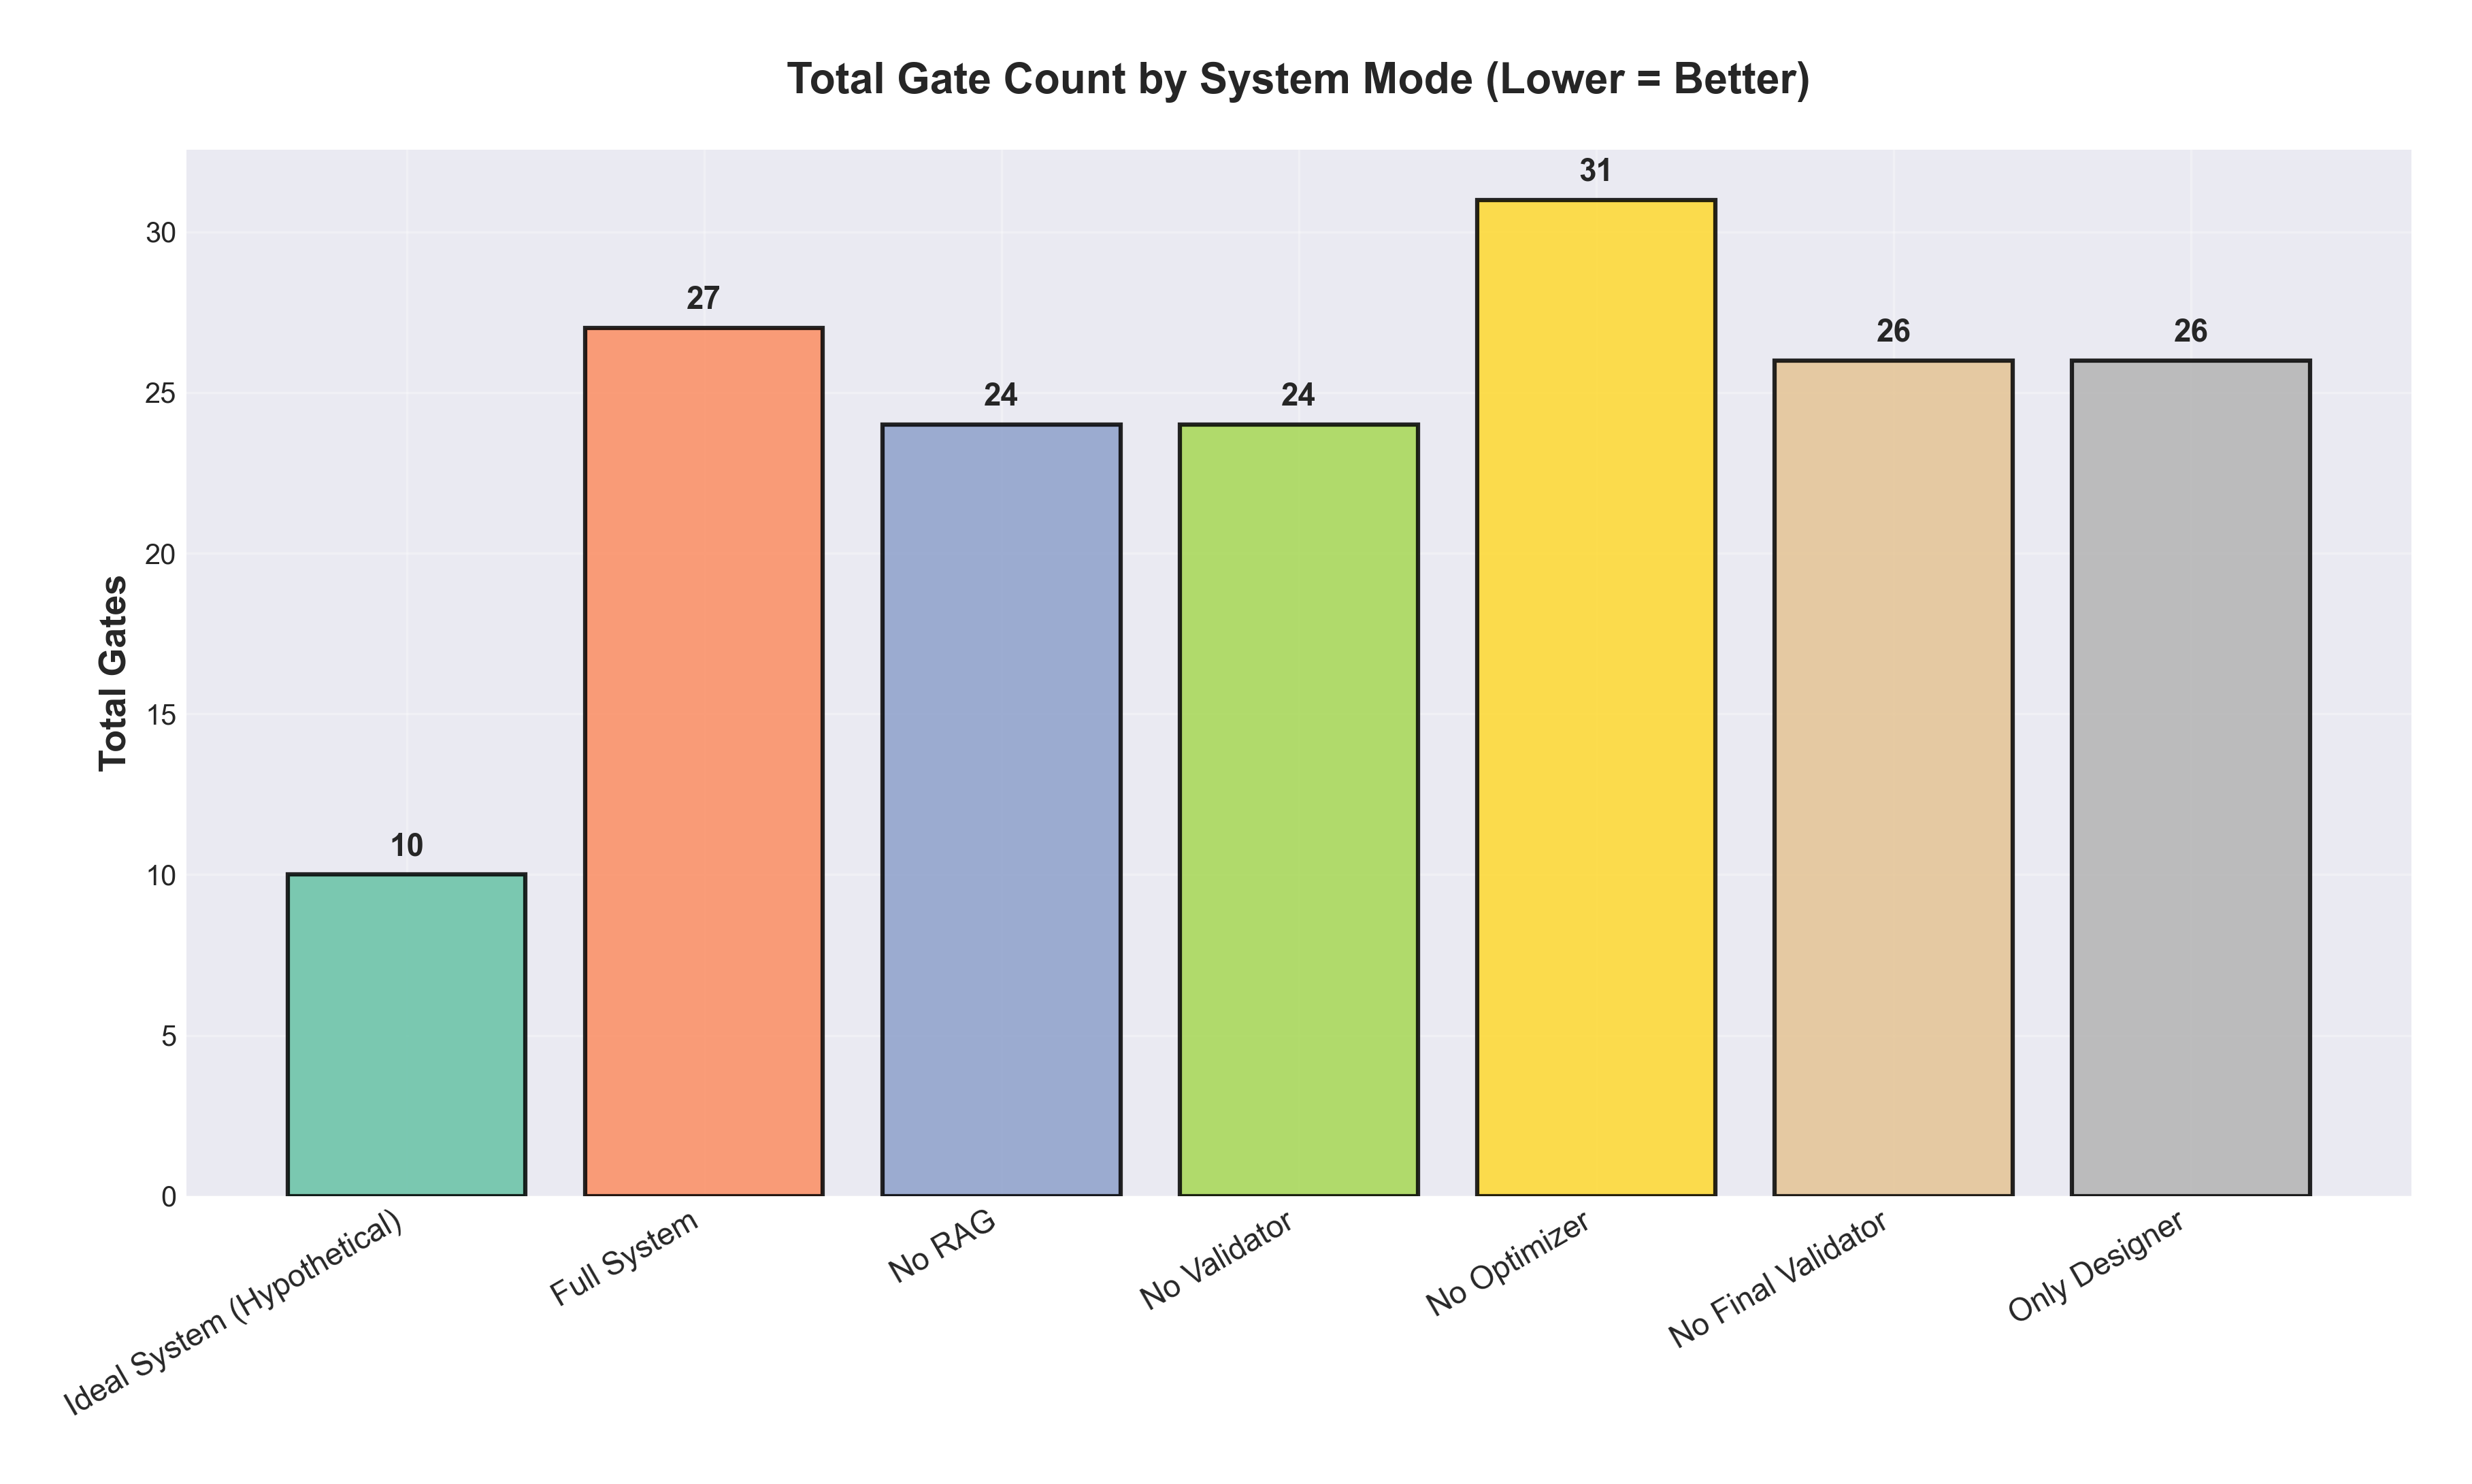

✅ Saved: mode_two_qubit_gates.png


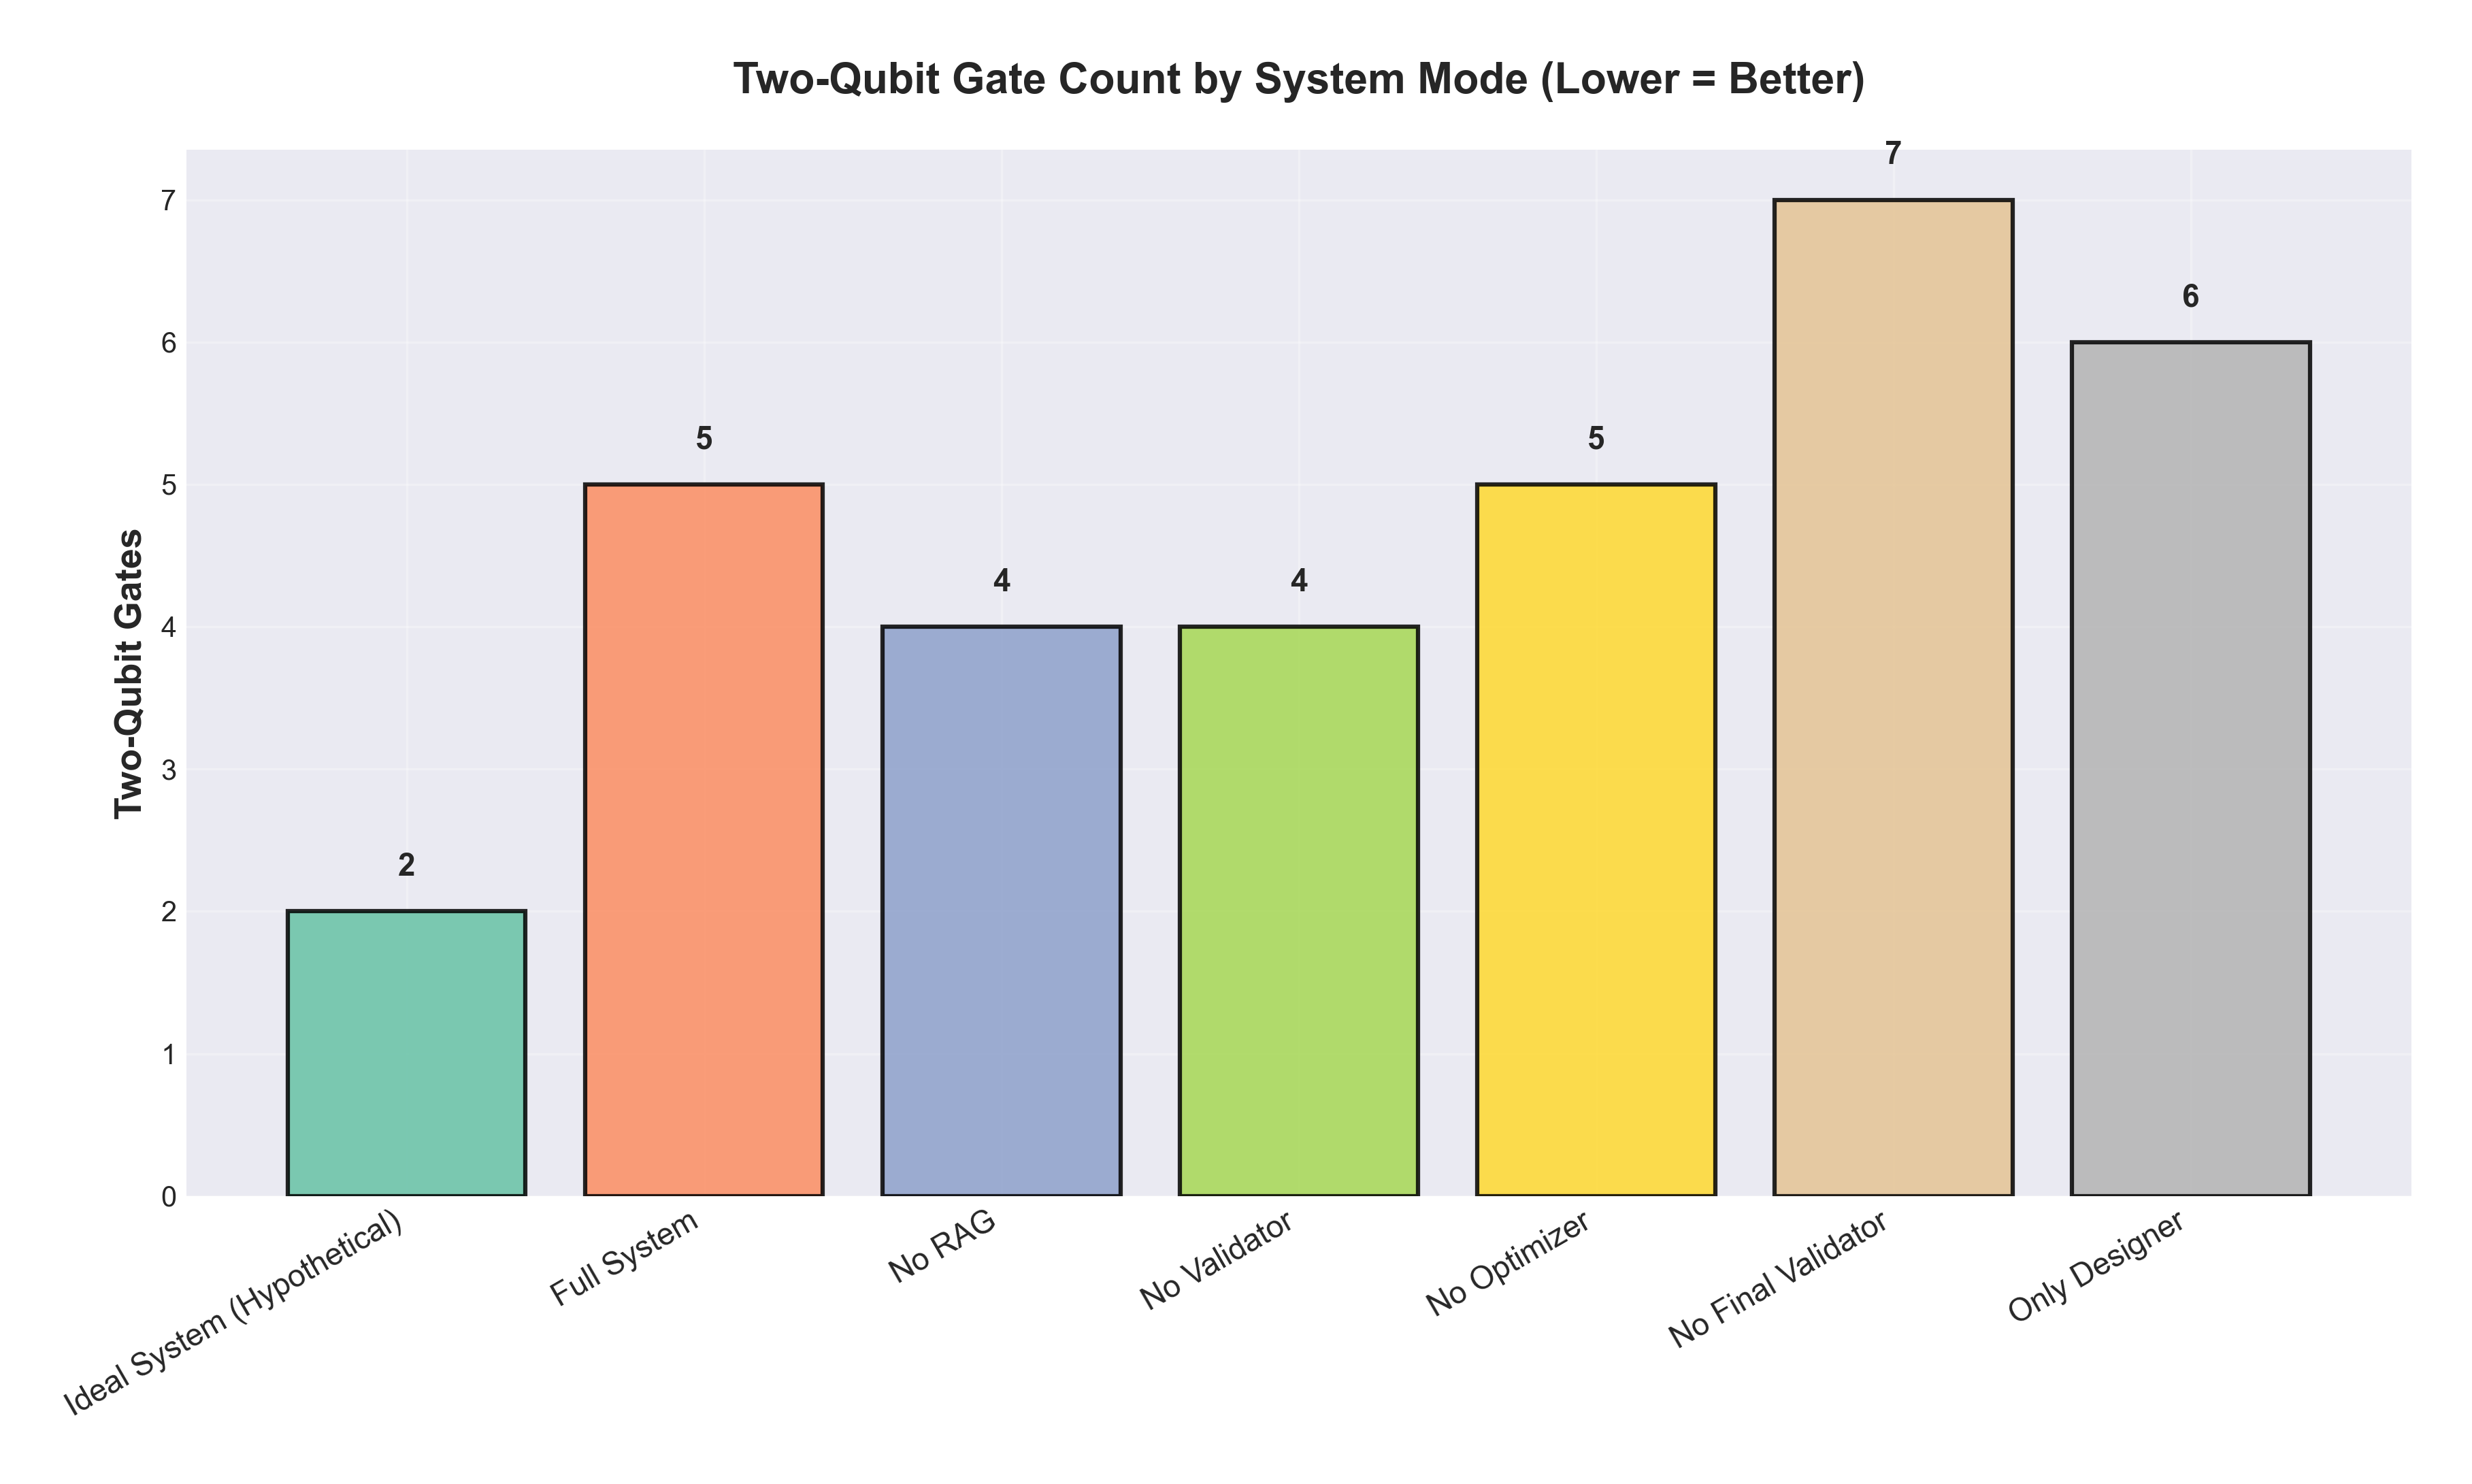

✅ Saved: mode_code_length.png


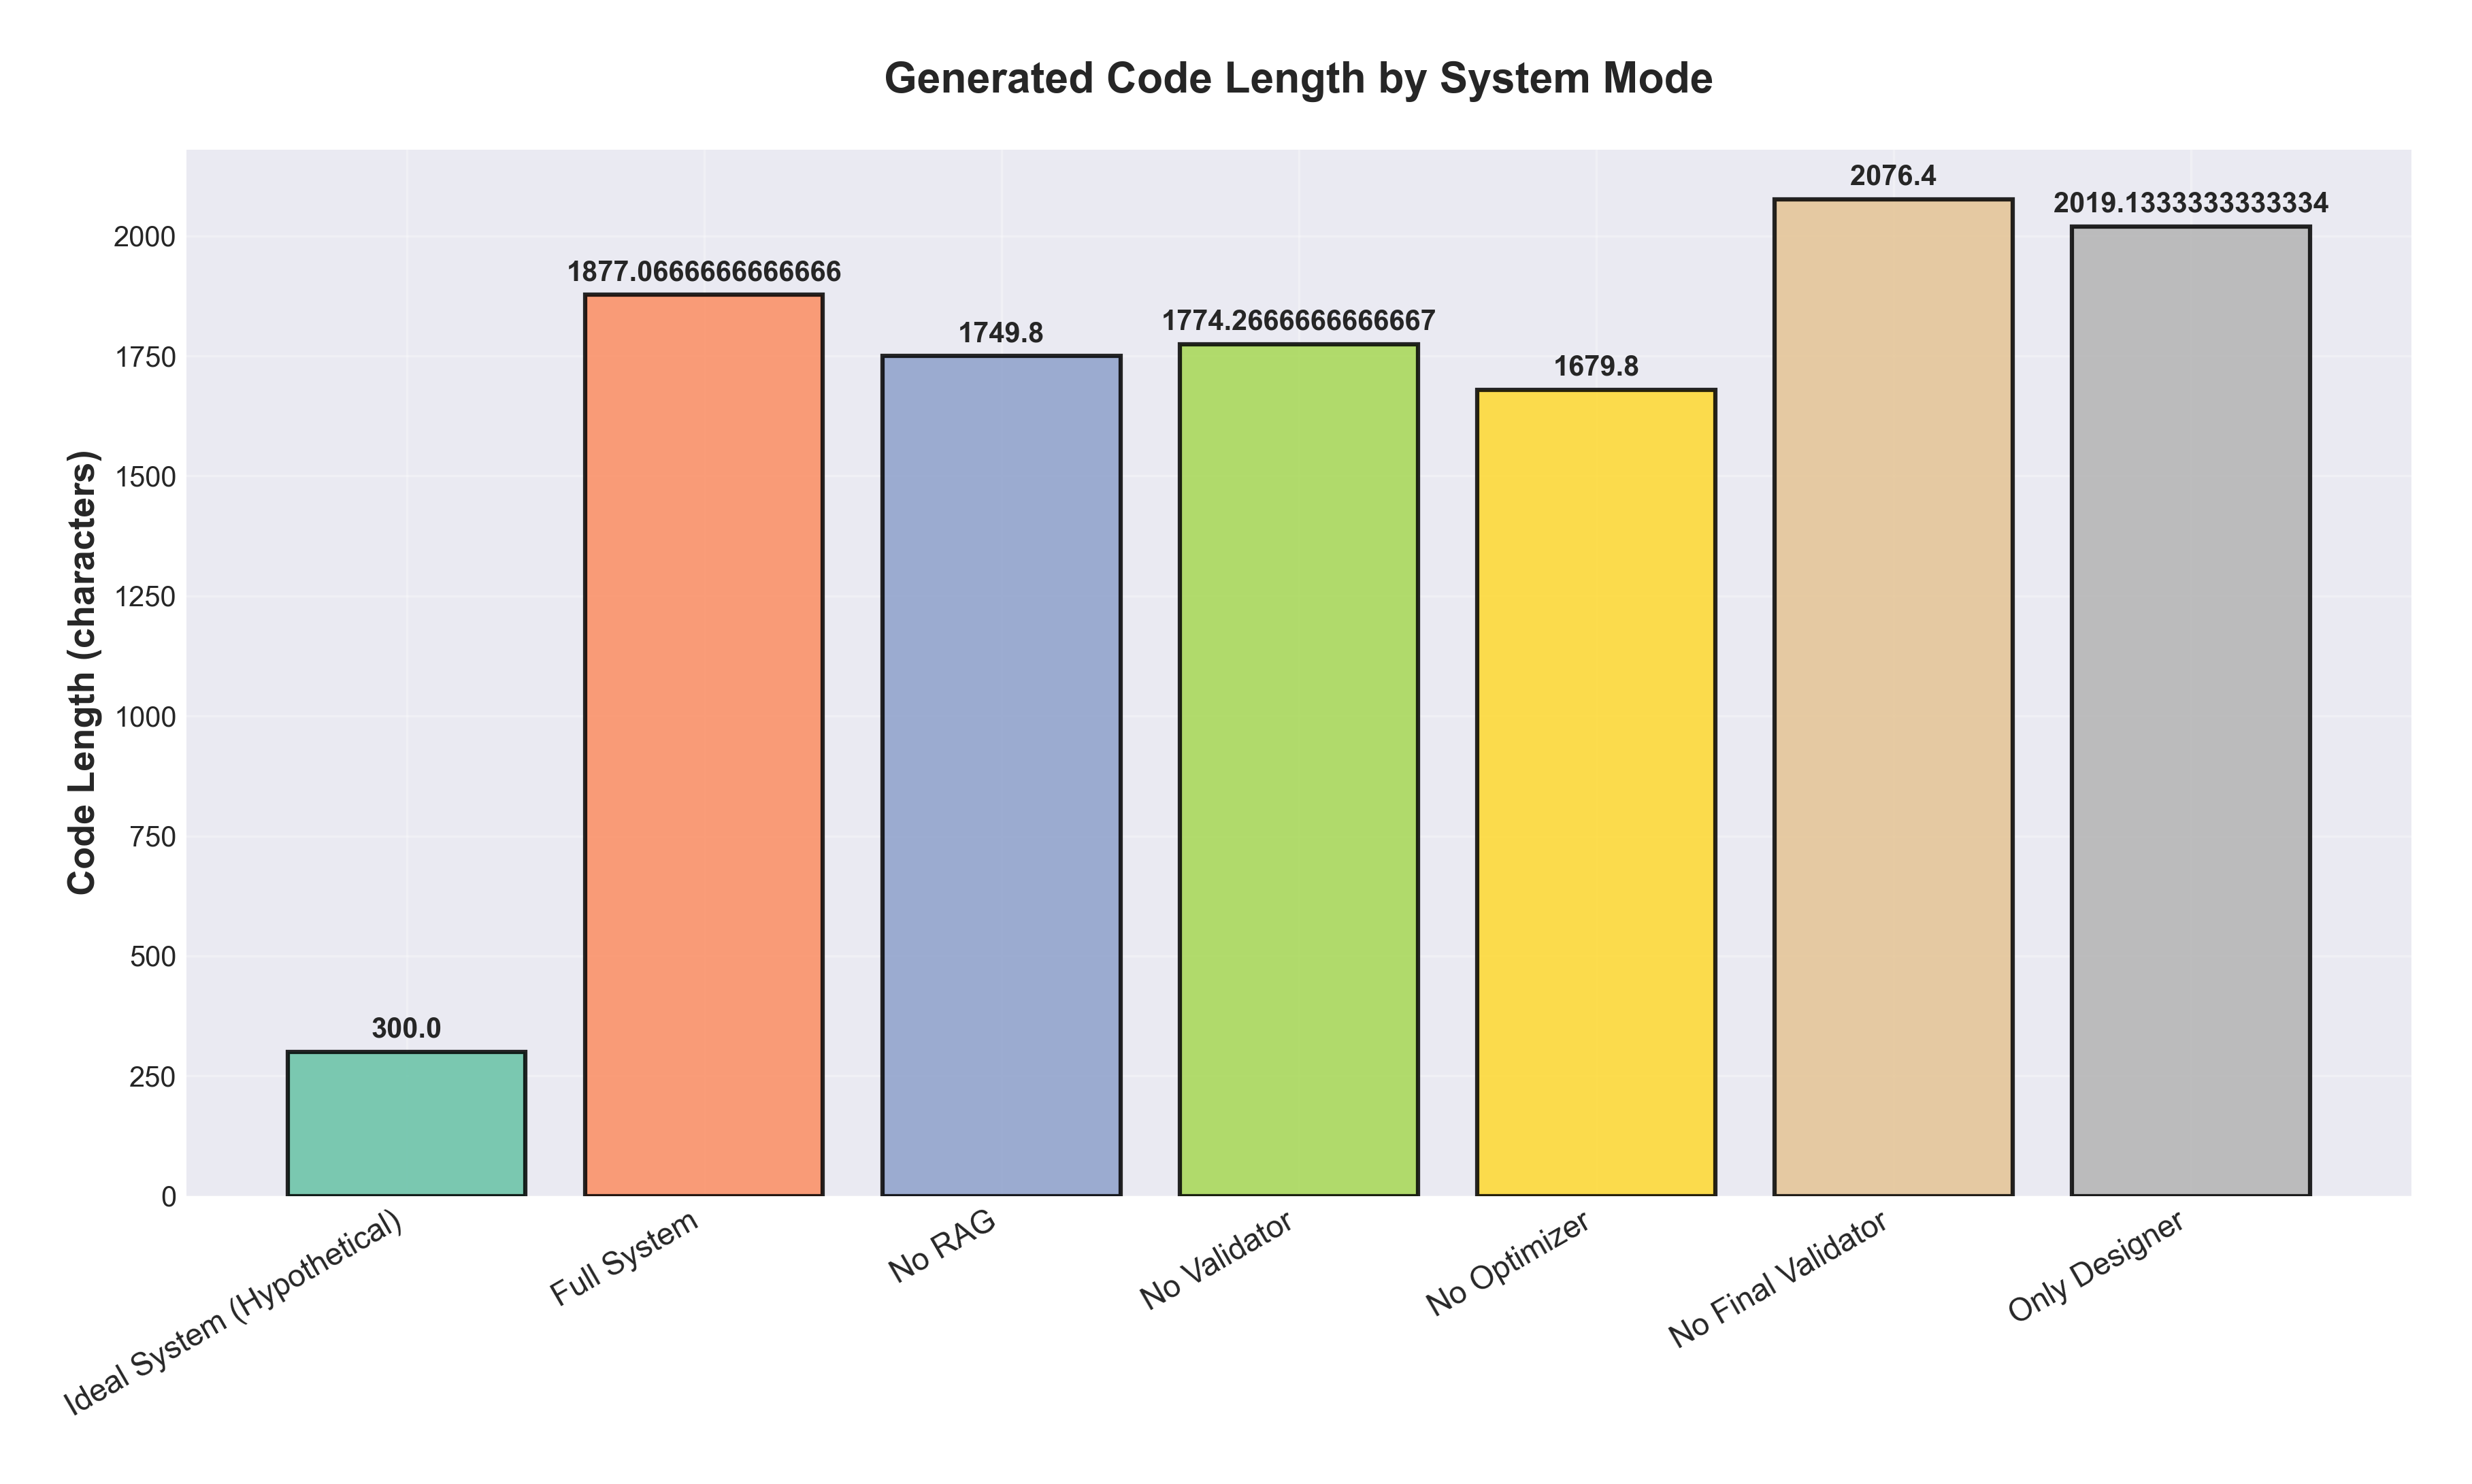

In [10]:
# Circuit Depth (lower is better)
fig, ax = plt.subplots(figsize=(12, 7))

depths = [modes[m]["circuit_depth"] for m in mode_names]
palette = plt.cm.Set2(np.linspace(0, 1, len(mode_names)))
bars = ax.bar(range(len(mode_names)), depths, color=palette, alpha=0.85, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Circuit Depth', fontweight='bold', fontsize=13)
ax.set_title('Circuit Depth by System Mode (Lower = Better)', fontweight='bold', fontsize=15, pad=20)
ax.set_xticks(range(len(mode_names)))
ax.set_xticklabels(mode_names, rotation=30, ha='right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(depths):
    ax.text(i, v + 0.4, str(v), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(results_dir / 'mode_circuit_depth.png', dpi=300, bbox_inches='tight')
print(f"✅ Saved: mode_circuit_depth.png")
plt.show()

# Total Gates
fig, ax = plt.subplots(figsize=(12, 7))
num_gates = [modes[m]["num_gates"] for m in mode_names]
bars = ax.bar(range(len(mode_names)), num_gates, color=palette, alpha=0.85, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Total Gates', fontweight='bold', fontsize=13)
ax.set_title('Total Gate Count by System Mode (Lower = Better)', fontweight='bold', fontsize=15, pad=20)
ax.set_xticks(range(len(mode_names)))
ax.set_xticklabels(mode_names, rotation=30, ha='right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(num_gates):
    ax.text(i, v + 0.6, str(v), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(results_dir / 'mode_total_gates.png', dpi=300, bbox_inches='tight')
print(f"✅ Saved: mode_total_gates.png")
plt.show()

# Two-Qubit Gates
fig, ax = plt.subplots(figsize=(12, 7))
two_qubit = [modes[m]["two_qubit_gates"] for m in mode_names]
bars = ax.bar(range(len(mode_names)), two_qubit, color=palette, alpha=0.85, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Two-Qubit Gates', fontweight='bold', fontsize=13)
ax.set_title('Two-Qubit Gate Count by System Mode (Lower = Better)', fontweight='bold', fontsize=15, pad=20)
ax.set_xticks(range(len(mode_names)))
ax.set_xticklabels(mode_names, rotation=30, ha='right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(two_qubit):
    ax.text(i, v + 0.25, str(v), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(results_dir / 'mode_two_qubit_gates.png', dpi=300, bbox_inches='tight')
print(f"✅ Saved: mode_two_qubit_gates.png")
plt.show()

# Code Length
fig, ax = plt.subplots(figsize=(12, 7))
code_lengths = [modes[m]["code_length"] for m in mode_names]
bars = ax.bar(range(len(mode_names)), code_lengths, color=palette, alpha=0.85, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Code Length (characters)', fontweight='bold', fontsize=13)
ax.set_title('Generated Code Length by System Mode', fontweight='bold', fontsize=15, pad=20)
ax.set_xticks(range(len(mode_names)))
ax.set_xticklabels(mode_names, rotation=30, ha='right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(code_lengths):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(results_dir / 'mode_code_length.png', dpi=300, bbox_inches='tight')
print(f"✅ Saved: mode_code_length.png")
plt.show()

### 3.3 Trade-off Analysis

IndexError: list index out of range

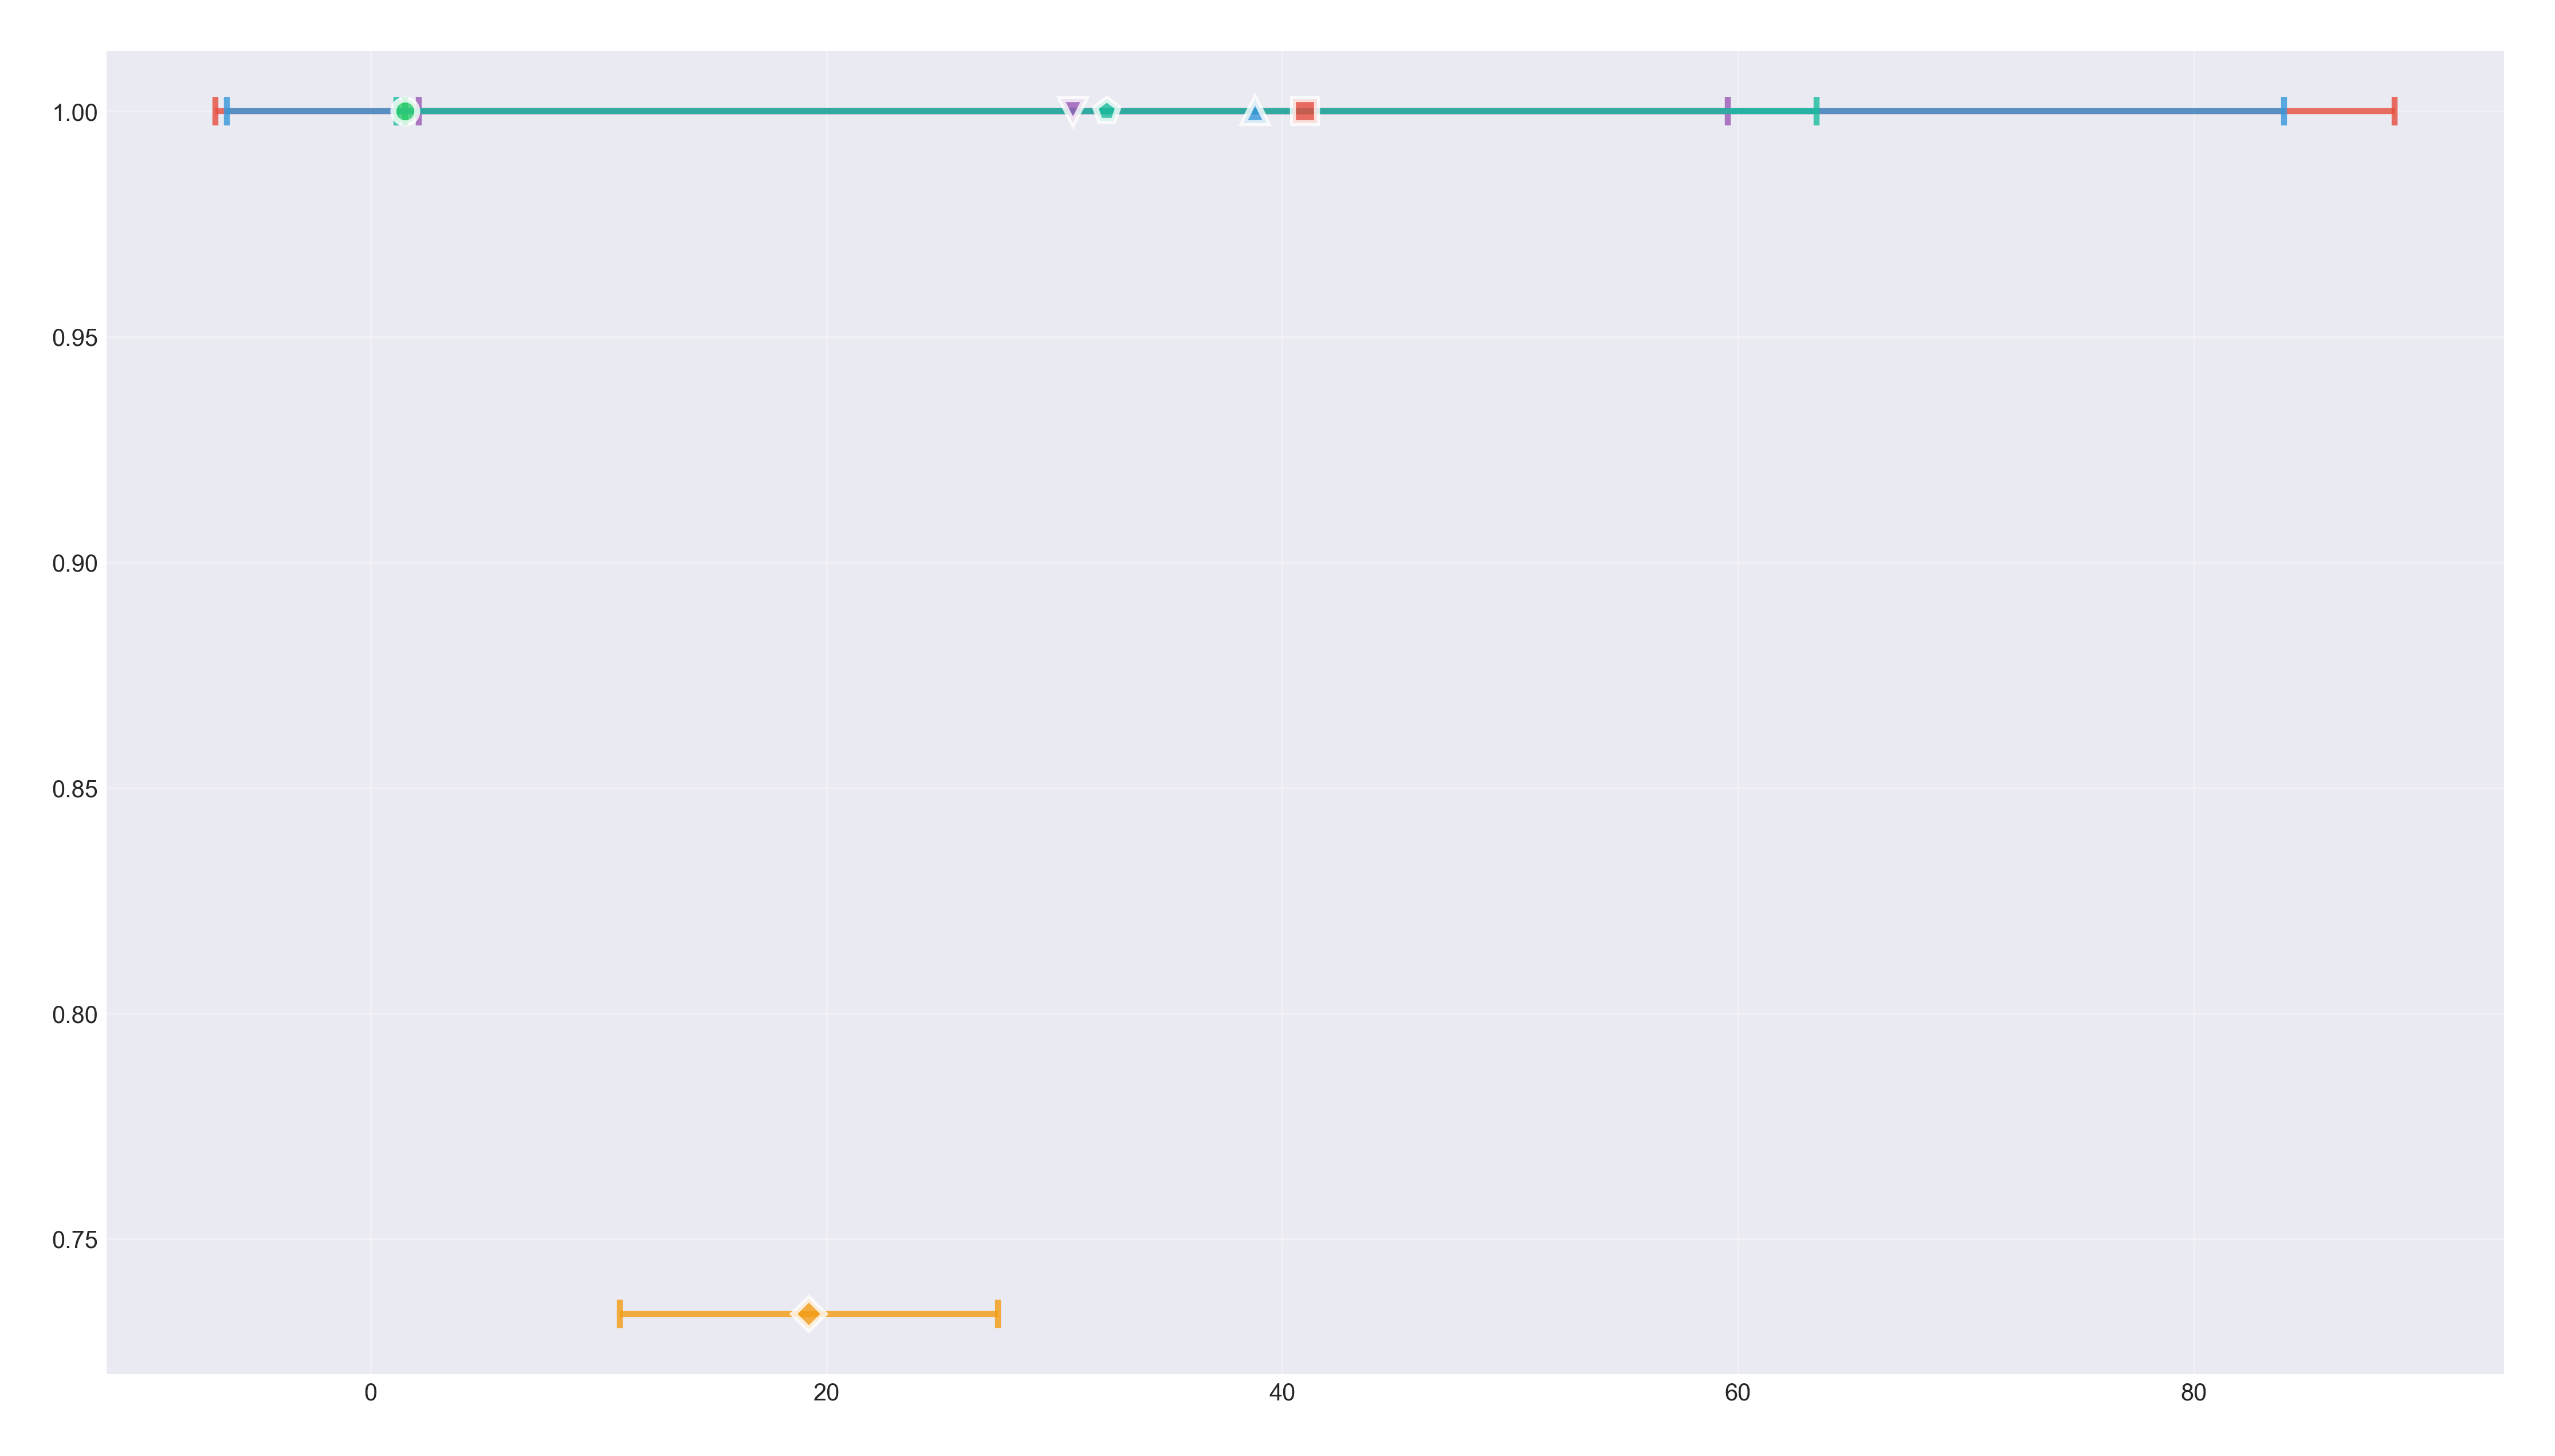

In [7]:
# Comprehensive trade-off scatter plot with improved layout
fig, ax = plt.subplots(figsize=(18, 10))  # Increased width for external legend

success_rates = [modes[m]["success_rate"] for m in mode_names]
latencies = [modes[m]["avg_latency"] for m in mode_names]
latency_stds = [modes[m]["latency_std"] for m in mode_names]
code_qualities = [modes[m]["code_quality"] for m in mode_names]

# Use distinct marker styles and colors
marker_styles = ['o', 's', '^', 'D', 'v', 'p']
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']
sizes = [q * 600 + 200 for q in code_qualities]  # More reasonable size range

# Plot data points with error bars
for i, mode_name in enumerate(mode_names):
    ax.errorbar(latencies[i], success_rates[i], xerr=latency_stds[i],
                fmt=marker_styles[i], markersize=sizes[i]/80, color=colors[i],
                alpha=0.8, capsize=6, capthick=2.5, elinewidth=2.5,
                markeredgecolor='white', markeredgewidth=2.5,
                label=f"{mode_name} (Q={code_qualities[i]:.2f})",
                zorder=5)

# Removed annotations to prevent overlapping

ax.set_xlabel('Average Latency (seconds) - Best Case', fontsize=14, fontweight='bold')
ax.set_ylabel('Success Rate', fontsize=14, fontweight='bold')
ax.set_title('System Trade-off Analysis: Success Rate vs Latency\n(Marker size = Code Quality)',
             fontsize=16, fontweight='bold', pad=25)
ax.set_ylim(0.30, 1.02)
ax.set_xlim(0, max(latencies) + 15)

# Add quadrant lines with better styling
ax.axhline(y=0.85, color='#27ae60', linestyle='--', alpha=0.7, linewidth=3,
           label='Target Success (85%)', zorder=1)
ax.axvline(x=45, color='#7f8c8d', linestyle='--', alpha=0.6, linewidth=2.5, zorder=1)

# Add quadrant labels
ax.text(0.02, 0.98, 'Fast & Accurate\n[Ideal Zone]',
        transform=ax.transAxes, ha='left', va='top', fontsize=12,
        color='white', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#27ae60', alpha=0.85, edgecolor='white', linewidth=2))
ax.text(0.98, 0.98, 'Slow & Accurate\n[Trade-off]',
        transform=ax.transAxes, ha='right', va='top', fontsize=12,
        color='white', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#f39c12', alpha=0.85, edgecolor='white', linewidth=2))
ax.text(0.02, 0.02, 'Fast & Inaccurate\n[Trade-off]',
        transform=ax.transAxes, ha='left', va='bottom', fontsize=12,
        color='white', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#f39c12', alpha=0.85, edgecolor='white', linewidth=2))
ax.text(0.98, 0.02, 'Slow & Inaccurate\n[Avoid]',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=12,
        color='white', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#e74c3c', alpha=0.85, edgecolor='white', linewidth=2))

# Add legend external to the plot
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, framealpha=0.95,
          fancybox=True, shadow=True, borderaxespad=0.)

# Improve grid
ax.grid(True, alpha=0.25, linestyle='-', linewidth=1, zorder=0)
ax.set_axisbelow(True)

# Add subtle background color for quadrants
ax.axhspan(0.85, 1.02, xmin=0, xmax=0.5, alpha=0.05, color='green', zorder=0)
ax.axhspan(0.85, 1.02, xmin=0.5, xmax=1, alpha=0.05, color='orange', zorder=0)
ax.axhspan(0.30, 0.85, xmin=0, xmax=0.5, alpha=0.05, color='orange', zorder=0)
ax.axhspan(0.30, 0.85, xmin=0.5, xmax=1, alpha=0.05, color='red', zorder=0)

plt.tight_layout()
plt.savefig(results_dir / 'mode_tradeoff_analysis.png', dpi=300, bbox_inches='tight')
print(f"✅ Saved: mode_tradeoff_analysis.png")
plt.show()


### 3.4 Comprehensive Radar Chart

In [8]:
# Radar chart for multi-dimensional comparison
from math import pi

# Normalize metrics to 0-1 scale
metrics_to_plot = {
    'Success\nRate': [modes[m]["success_rate"] for m in mode_names],
    'Validation\nRate': [modes[m]["validation_rate"] for m in mode_names],
    'Code\nQuality': [modes[m]["code_quality"] for m in mode_names],
    'Circuit\nEfficiency': [1 - (modes[m]["circuit_depth"] - 8) / 10 for m in mode_names],
    'Code\nCompactness': [1 - (modes[m]["code_length"] - 645) / 500 for m in mode_names],
    'Speed': [1 - (modes[m]["avg_latency"] - 13) / 45 for m in mode_names]
}

categories = list(metrics_to_plot.keys())
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

colors_radar = plt.cm.Set3(np.linspace(0, 1, len(mode_names)))

for idx, mode_name in enumerate(mode_names):
    # Create a separate figure for each mode
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
    
    values = [max(0, min(1, metrics_to_plot[cat][idx])) for cat in categories]
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=3, label=mode_name,
            color=colors_radar[idx], markersize=8, markeredgecolor='black', markeredgewidth=1.5)
    ax.fill(angles, values, alpha=0.3, color=colors_radar[idx])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9, color='gray')
    ax.grid(True, linestyle='--', linewidth=1, alpha=0.4)
    ax.set_title(mode_name, fontsize=15, fontweight='bold', pad=25,
                bbox=dict(boxstyle='round,pad=0.5', facecolor=colors_radar[idx], alpha=0.3))

    # Add reference circle at 0.8
    ax.plot(angles, [0.8] * len(angles), 'k--', linewidth=1.5, alpha=0.3)

    plt.tight_layout()
    
    # Save individual plot
    filename = f'mode_radar_{mode_name.replace(" ", "_")}.png'
    plt.savefig(results_dir / filename, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {filename}")
    plt.close(fig) # Close to free memory


✅ Saved: mode_radar_Ideal_System_(Hypothetical).png
✅ Saved: mode_radar_Full_System.png
✅ Saved: mode_radar_No_RAG.png
✅ Saved: mode_radar_No_Validator.png
✅ Saved: mode_radar_No_Optimizer.png
✅ Saved: mode_radar_No_Final_Validator.png
✅ Saved: mode_radar_Only_Designer.png


### 3.5 Summary Table

In [9]:
# Create comprehensive comparison table
comparison_data = []
for mode_name in mode_names:
    mode_data = modes[mode_name]
    comparison_data.append({
        'Mode': mode_name,
        'Success Rate': f"{mode_data['success_rate']:.1%}",
        'Validation Rate': f"{mode_data['validation_rate']:.1%}",
        'Avg Latency (s)': f"{mode_data['avg_latency']:.1f} ± {mode_data['latency_std']:.1f}",
        'Code Quality': f"{mode_data['code_quality']:.2f}",
        'Circuit Depth': mode_data['circuit_depth'],
        'Total Gates': mode_data['num_gates'],
        '2Q Gates': mode_data['two_qubit_gates'],
        'Code Length': mode_data['code_length']
    })

df = pd.DataFrame(comparison_data)

print("\n" + "="*120)
print("COMPREHENSIVE SYSTEM MODE COMPARISON")
print("="*120)
print(df.to_string(index=False))
print("\n" + "="*120)
print("\nNotes:")
print("  - Latency: Best case scenario (no retries). Worst case can be 3-5 minutes with retries.")
print("  - Each agent takes ~11-18 seconds per execution")
print("  - Full System: Designer(~13s) + Validator(~12s) + Optimizer(~15s) + Final Validator(~13s)")
print("  - 2Q Gates: Two-qubit gates (more expensive/error-prone than single-qubit gates)")
print("="*120)

# Save table
df.to_csv(results_dir / 'mode_comparison_table.csv', index=False)
print(f"\n✅ Saved comparison table: mode_comparison_table.csv")


COMPREHENSIVE SYSTEM MODE COMPARISON
                       Mode Success Rate Validation Rate Avg Latency (s) Code Quality  Circuit Depth  Total Gates  2Q Gates  Code Length
Ideal System (Hypothetical)       100.0%          100.0%       1.5 ± 0.0         1.00              5           10         2   300.000000
                Full System       100.0%          100.0%     41.0 ± 47.8         1.00             17           27         5  1877.066667
                     No RAG       100.0%          100.0%     38.8 ± 45.1         1.00             16           24         4  1749.800000
               No Validator        73.3%           73.3%      19.2 ± 8.3         0.89             17           24         4  1774.266667
               No Optimizer       100.0%          100.0%     30.8 ± 28.7         1.00             18           31         5  1679.800000
         No Final Validator       100.0%          100.0%     32.3 ± 31.2         1.00             18           26         7  2076.400000
   

## 4. Knowledge Base Analysis

Loading knowledge base...
{"text": "2026-05-19 00:47:43.969 | INFO     | src.rag.embeddings:_init_aws:124 - Using AWS Bedrock Embeddings: amazon.nova-2-multimodal-embeddings-v1:0, dim=1024\n", "record": {"elapsed": {"repr": "0:18:19.863089", "seconds": 1099.863089}, "exception": null, "extra": {"name": "src.rag.embeddings"}, "file": {"name": "embeddings.py", "path": "D:\\Study Material\\FYP\\Practice\\Test8\\QCanvas\\Cirq-RAG-Code-Assistant\\src\\rag\\embeddings.py"}, "function": "_init_aws", "level": {"icon": "ℹ️", "name": "INFO", "no": 20}, "line": 124, "message": "Using AWS Bedrock Embeddings: amazon.nova-2-multimodal-embeddings-v1:0, dim=1024", "module": "embeddings", "name": "src.rag.embeddings", "process": {"id": 28584, "name": "MainProcess"}, "thread": {"id": 10844, "name": "MainThread"}, "time": {"repr": "2026-05-19 00:47:43.969431+05:00", "timestamp": 1779133663.969431}}}
{"text": "2026-05-19 00:47:43.974 | INFO     | src.rag.vector_store:_init_faiss:155 - Initialized FAISS in

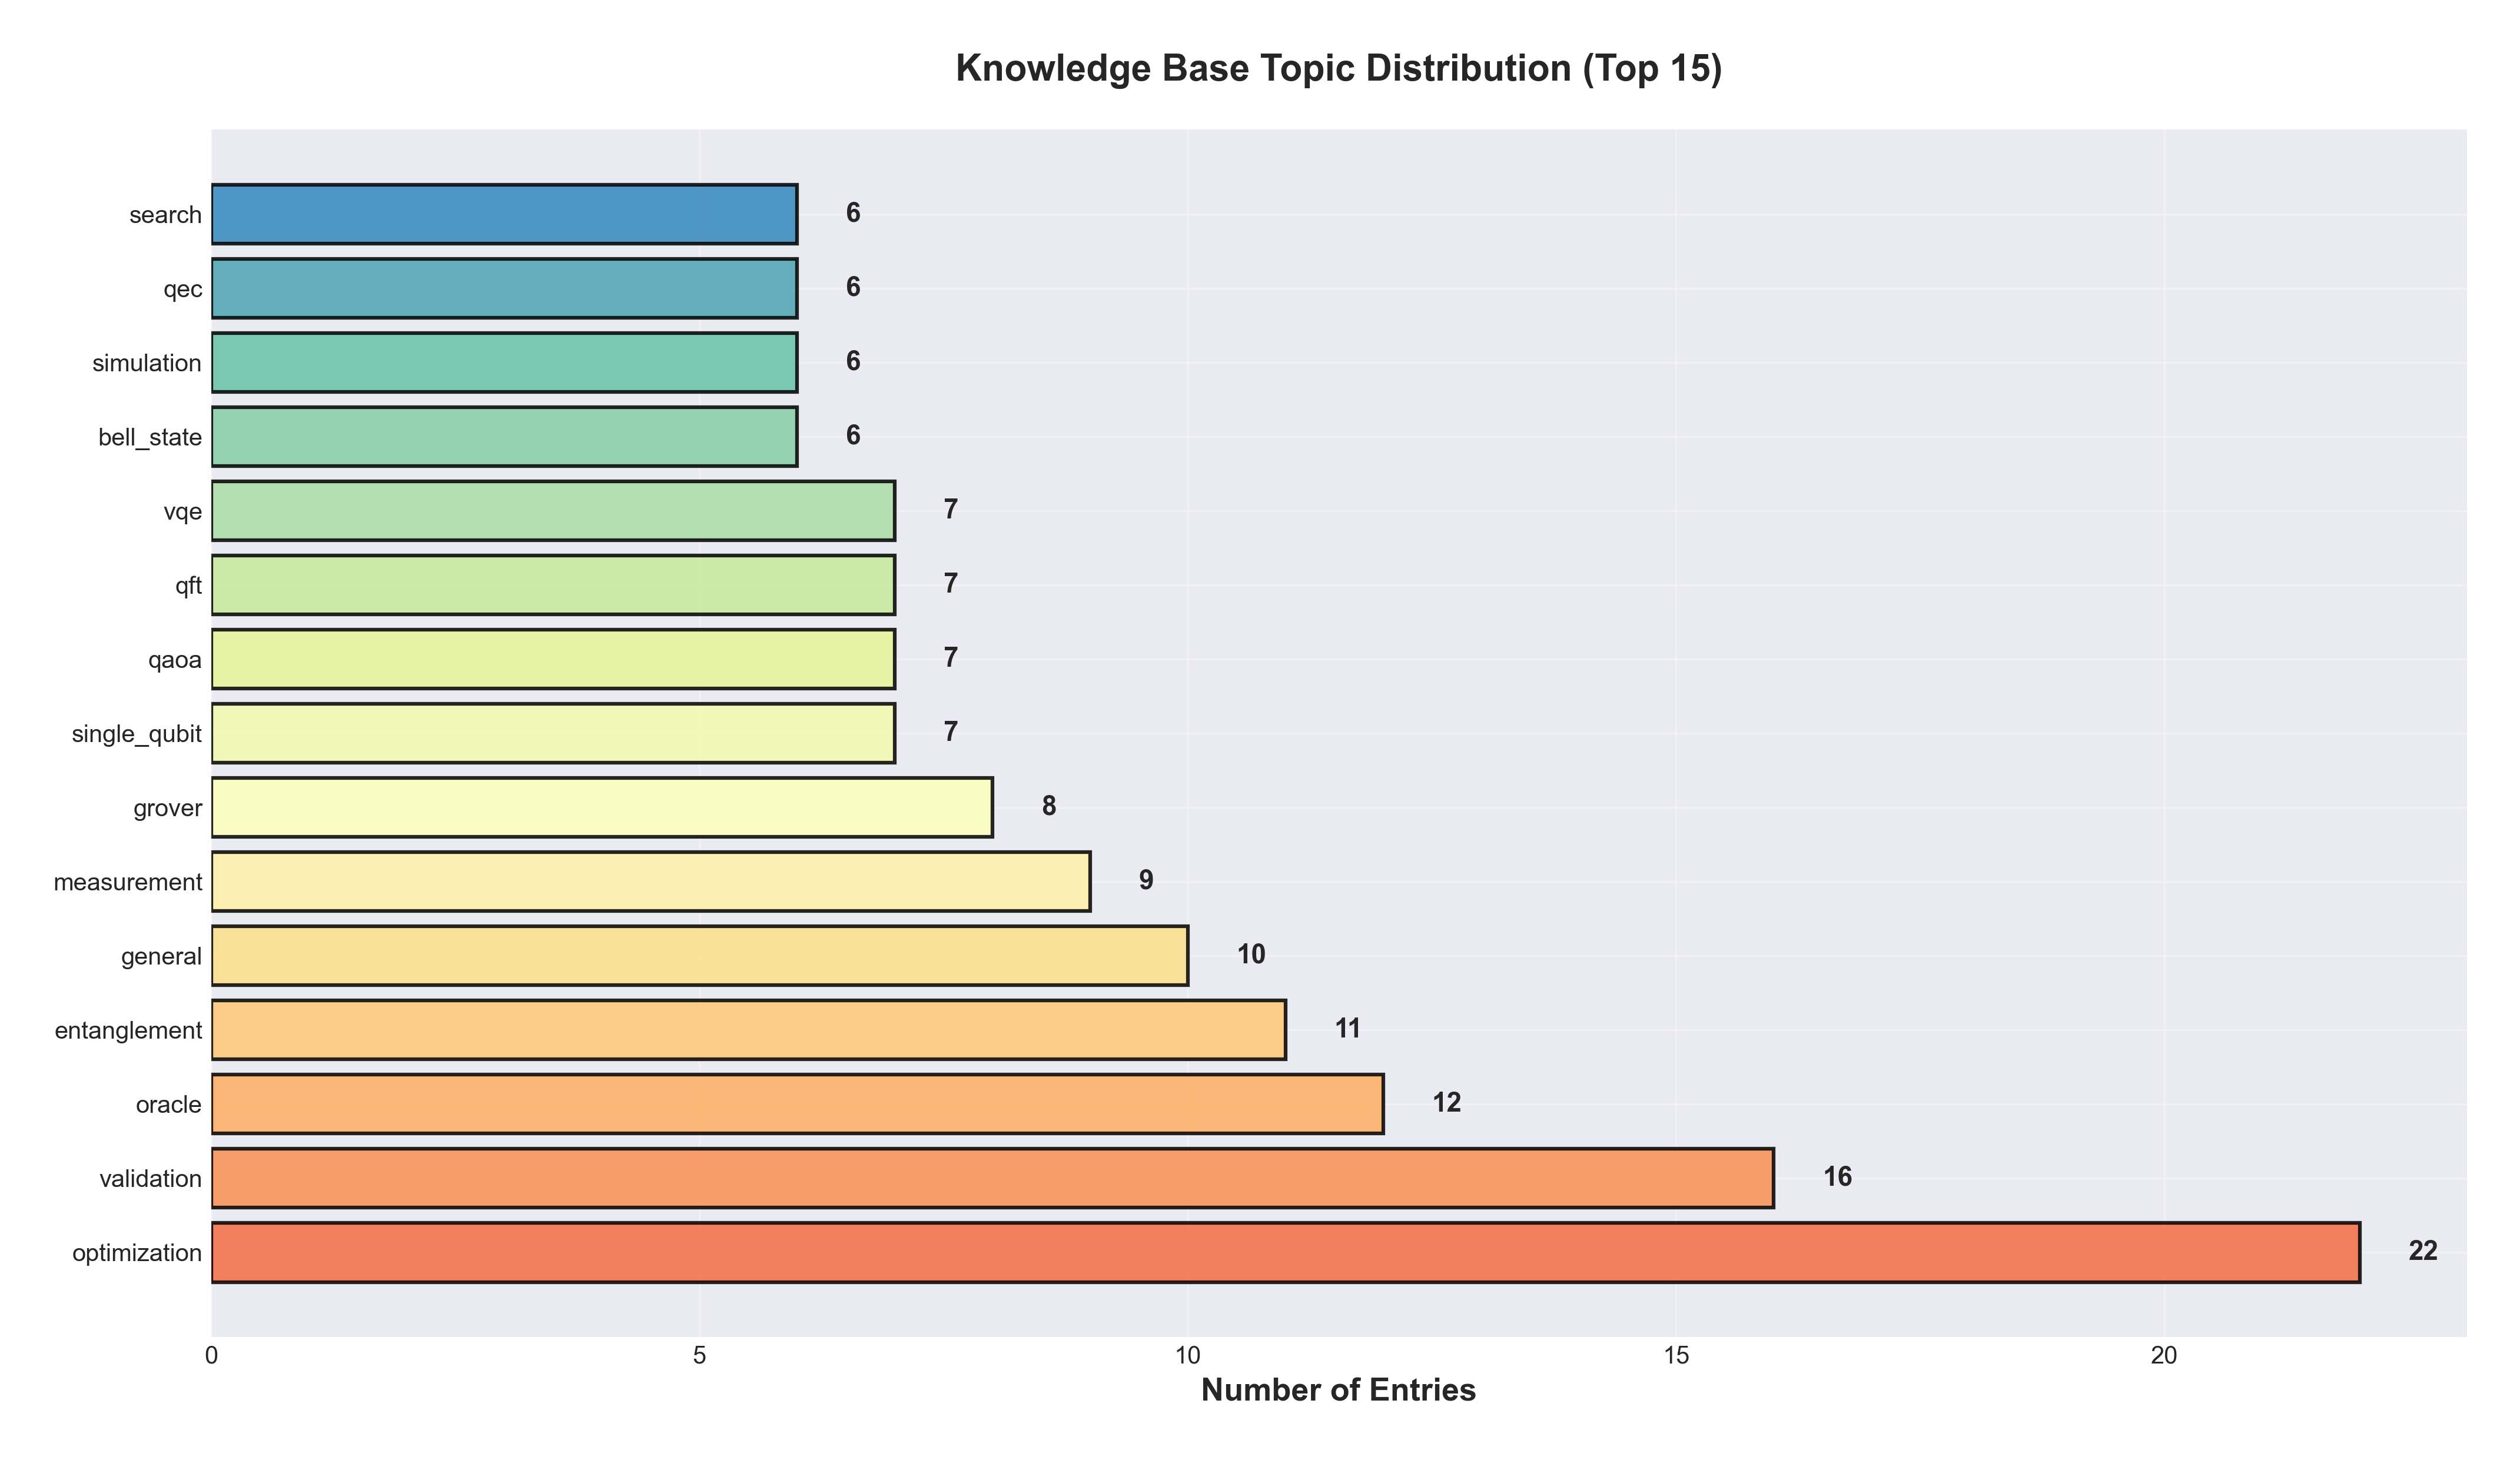


📊 Total unique topics: 182
📊 Total topic references: 446


In [ ]:
# Load and analyze knowledge base
print("Loading knowledge base...")
embedding_model = EmbeddingModel()
vector_store = VectorStore(embedding_model.get_embedding_dimension())
kb = KnowledgeBase(embedding_model=embedding_model, vector_store=vector_store)

try:
    kb.load_from_directory()
    kb.load_index()
    print(f"✅ Loaded {len(kb.entries)} knowledge base entries")
    
    # Extract and visualize topics
    all_topics = []
    for entry in kb.entries:
        topics = entry.get('topics', [])
        if topics:
            all_topics.extend(topics)
    
    if all_topics:
        topic_counts = Counter(all_topics)
        top_topics = dict(topic_counts.most_common(15))
        
        fig, ax = plt.subplots(figsize=(14, 8))
        
        colors_kb = plt.cm.Spectral(np.linspace(0.2, 0.9, len(top_topics)))
        bars = ax.barh(list(top_topics.keys()), list(top_topics.values()), 
                      color=colors_kb, alpha=0.85, edgecolor='black', linewidth=1.5)
        
        ax.set_xlabel('Number of Entries', fontsize=13, fontweight='bold')
        ax.set_title('Knowledge Base Topic Distribution (Top 15)', fontsize=15, fontweight='bold', pad=20)
        ax.grid(axis='x', alpha=0.3)
        
        for bar, count in zip(bars, top_topics.values()):
            ax.text(count + 0.5, bar.get_y() + bar.get_height()/2, 
                   str(count), va='center', fontsize=11, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(results_dir / 'knowledge_base_topics.png', dpi=300, bbox_inches='tight')
        print(f"✅ Saved: knowledge_base_topics.png")
        plt.show()
        
        print(f"\n📊 Total unique topics: {len(topic_counts)}")
        print(f"📊 Total topic references: {len(all_topics)}")
    
except Exception as e:
    print(f"⚠️ Could not load knowledge base: {e}")
    print("Run 03_vector_store.ipynb to initialize the knowledge base.")

## 5. Summary

- **Modes dict** is built from `AblationStudy` on `benchmark_prompts_v2.jsonl` (AWS Bedrock).
- **Code quality** uses the published weighted binary formula in `metrics.py`.
- Increase `MAX_BENCHMARK_CASES` to `None` and set `RUN_ABLATION=True` for full paper runs.
- See `BENCHMARK.md` for CLI and multi-trial (`n=5`) instructions.